In [1]:
from llm_consistency.core.paths import ProjectPaths
from llm_consistency.datasets.registry import get_dataset_spec
import pandas as pd

dataset = "TruthfulQA"
experiment_flag = "v00"
temperature = 0.0

paths = ProjectPaths()
rp = paths.run_paths(dataset, experiment_flag)
conf = rp.conf_suffix(temperature=temperature)

d = pd.read_csv(rp.answers_all_models_file("both", conf))


df = pd.read_csv(rp.grades_all_judges_file("both"))


# print(d.shape)
print(df.shape)
with pd.option_context(
    'display.max_colwidth', None,
    'display.max_columns', None,
    'display.expand_frame_repr', False
):
    # display(df1[(df1.idx == 1499) & (df1.model == "gpt-3.5-turbo")])
    # display(df1)
    pass


(368448, 12)


In [2]:
df.idx.nunique()

511

In [3]:
import pandas as pd

def aggregate_judges_list_based(df):
    qid_cols = ["model", "idx", "paraphrased_question"]

    grouped = (
        df
        .groupby(qid_cols)
        .agg(
            original_question=("original_question", "first"),
            verdicts=("verdict", list),
            evaluators=("evaluator", list),
        )
        .reset_index()
    )

    # ---- overall stats ----
    def overall_stats(vs):
        vc = pd.Series(vs).value_counts()
        return pd.Series({
            "num_judges": len(vs),
            "num_unique": vc.size,
            "all_same": vc.size == 1,
            "max_agreement_count": vc.max(),
            "max_agreement_value": vc.idxmax(),
        })

    grouped[[
        "num_judges",
        "num_unique",
        "all_same",
        "max_agreement_count",
        "max_agreement_value",
    ]] = grouped["verdicts"].apply(overall_stats)

    # ---- GPT-only stats ----
    def gpt_stats(row):
        gpt_verdicts = [
            v for v, e in zip(row["verdicts"], row["evaluators"])
            if "gpt" in e
        ]

        if len(gpt_verdicts) == 0:
            return pd.Series({
                "gpt_num_judges": 0,
                "gpt_num_unique": pd.NA,
                "gpt_agree": pd.NA,
                "gpt_max_agreement_count": pd.NA,
                "gpt_max_agreement_value": pd.NA,
            })

        vc = pd.Series(gpt_verdicts).value_counts()
        return pd.Series({
            "gpt_num_judges": len(gpt_verdicts),
            "gpt_num_unique": vc.size,
            "gpt_agree": vc.size == 1,
            "gpt_max_agreement_count": vc.max(),
            "gpt_max_agreement_value": vc.idxmax(),
        })

    grouped[[
        "gpt_num_judges",
        "gpt_num_unique",
        "gpt_agree",
        "gpt_max_agreement_count",
        "gpt_max_agreement_value",
    ]] = grouped.apply(gpt_stats, axis=1)

    return grouped.drop(columns="verdicts")

agg = aggregate_judges_list_based(df)

print(agg.shape)


(92112, 15)


In [4]:
from analysis_utils import df_to_acl_icml_table, prep_for_paper, prep, model_name_map

In [5]:


df = agg.copy()
print(df.shape)
df = df[df.gpt_agree & (df.max_agreement_count >= 3)]
print(df.shape)
evals = df.copy()
df = agg.copy()
vo = df[df.original_question == df.paraphrased_question].copy()   # from original_only group
vp = df[df.original_question != df.paraphrased_question].copy()  # from paraphrased_only group
print(vo.shape, vp.shape)
vo = vo[vo.gpt_agree & (vo.max_agreement_count >= 3)]
vp = vp[vp.gpt_agree & (vp.max_agreement_count >= 3)]
print(vo.shape, vp.shape)
# print(vo.columns)
# vo = vo[vo.gpt_agree & (vo.max_agreement_count >= 5)]
# vp = vp[vp.gpt_agree & (vp.max_agreement_count >= 5)]
# print(vo.shape, vp.shape)

(92112, 15)
(63921, 15)
(9709, 15) (82403, 15)
(6978, 15) (56943, 15)


## HERE the actual analysis begins!

In [6]:
def original_distribution(df_orig, col="max_agreement_value", suffix="_orig"):
    """
    df_orig: verdicts_original (one row per (idx, model))
    Returns: DataFrame indexed by (idx, model) with columns A_orig, B_orig, C_orig
    """
    dist = pd.get_dummies(df_orig[col]) #\
            #    .reindex(columns=["A", "B", "C"], fill_value=0)

    # dist.columns = [c + "_orig" for c in dist.columns]
    dist.columns = dist.columns.astype(str) + suffix

    # Set multi-index (idx, model) for alignment with paraphrased
    dist["idx"] = df_orig["idx"]
    dist["model"] = df_orig["model"]
    return dist.set_index(["idx", "model"])

def paraphrased_distribution(df_para, col="max_agreement_value", suffix="_para"):
    """
    df_para: verdicts_paraphrased (many rows per (idx, model))
    Returns: normalized distribution per (idx, model) with A_para, B_para, C_para
    """
    norm = (
        df_para.groupby(["idx", "model"])[col]
        .value_counts(normalize=True)
        .unstack(fill_value=0)
        # .reindex(columns=["A", "B", "C"], fill_value=0)
    )

    # normalize row-wise inside each (idx, model)
    # norm = counts.div(counts.sum(axis=1), axis=0)
    # norm.columns = [c + suffix for c in norm.columns]
    norm.columns = norm.columns.astype(str) + suffix

    return norm

import numpy as np
def iid_mismatch_metric(group, col="max_agreement_value", suffix=""):
    p = group[col].value_counts(normalize=True)
    iid_mismatch_prob = 1 - (p ** 2).sum()
    distinct_answers = p.size
    mode_share = p.max()
    entropy = -(p * np.log(p)).sum()

    res = {
        "iid_mismatch_prob": iid_mismatch_prob,
        "distinct_classes": int(distinct_answers), # this is the number of distinct answers or labels
        "mode_share": mode_share,
        "entropy": entropy,
        "num_paraphrases": len(group),
        "normalized_entropy": entropy / np.log(len(group)) if len(group) > 1 else 0.0,
    }
    if suffix:
        res = {k + suffix: v for k, v in res.items()}
    return pd.Series(res)


In [7]:
vpp = pd.concat([vp, vo], ignore_index=True)
orig_dist = original_distribution(vo)
para_dist = paraphrased_distribution(vp)
para_dist2 = vp.groupby(["idx", "model"])[["max_agreement_value"]].apply(iid_mismatch_metric)
# para_dist2 = vp.groupby(["idx", "model"])["max_agreement_value"].apply(iid_mismatch_metric_df)
para_dist2["distinct_classes"] = para_dist2["distinct_classes"].astype("int64")
para_dist2["num_paraphrases"] = para_dist2["num_paraphrases"].astype("int64")

su = "_both"
both_dist = paraphrased_distribution(vpp, suffix=su)
both_dist2 = vpp.groupby(["idx", "model"])[["max_agreement_value"]].apply(iid_mismatch_metric, suffix=su)
both_dist2["distinct_classes"+su] = both_dist2["distinct_classes"+su].astype("int64")
both_dist2["num_paraphrases"+su] = both_dist2["num_paraphrases"+su].astype("int64")


print(orig_dist.shape, para_dist.shape, para_dist2.shape, both_dist.shape, both_dist2.shape)

# merged_dist = orig_dist.join(para_dist, how="inner")
merged = (
    orig_dist
    .join(para_dist, how="inner")
    .join(para_dist2, how="inner")
)
merged2 = (
    orig_dist
    .join(para_dist, how="inner")
    .join(para_dist2, how="inner")
    .join(both_dist, how="inner")
    .join(both_dist2, how="inner")
)
print(merged.shape, merged2.shape)
aligned = merged.copy()
aligned = merged2.copy()
print(aligned.columns)
for subset in ["orig", "para", "both"]:
    labels = ["correct_", "incorrect_", "not_attempted_"]
    cols = [label + subset for label in labels]

    aligned[f"{subset}_label"] = merged2[cols].idxmax(axis=1).str.replace(f"_{subset}", "")
    vals = merged2[cols]

    row_max = vals.max(axis=1)
    num_max = vals.eq(row_max, axis=0).sum(axis=1)

    # aligned[f"{subset}_label"] = np.where(
    #     num_max == 1,
    #     vals.idxmax(axis=1).str.replace(f"_{subset}", ""),
    #     "tie"
    # )

    aligned[f"{subset}_is_tie"] = num_max > 1
    def tied_labels(row):
        m = row.max()
        return tuple(
            c.replace(f"_{subset}", "")
            for c in cols if row[c] == m
        )

    aligned[f"{subset}_tied_labels"] = merged2[cols].apply(tied_labels, axis=1)


# aligned["orig_label"] = merged[["A_orig", "B_orig", "C_orig"]].idxmax(axis=1).str.replace("_orig", "")
# aligned["para_label"] = merged[["A_para", "B_para", "C_para"]].idxmax(axis=1).str.replace("_para", "")
# aligned["both_label"] = merged2[["A_both", "B_both", "C_both"]].idxmax(axis=1).str.replace("_both", "")
aligned["match"] = aligned["orig_label"] == aligned["para_label"]
# aligned["match_"] = aligned["orig_label"] == aligned["both_label"]
print(aligned.shape)


(6978, 3) (9340, 3) (9340, 6) (9419, 3) (9419, 6)
(6899, 12) (6899, 21)
Index(['correct_orig', 'incorrect_orig', 'not_attempted_orig', 'correct_para',
       'incorrect_para', 'not_attempted_para', 'iid_mismatch_prob',
       'distinct_classes', 'mode_share', 'entropy', 'num_paraphrases',
       'normalized_entropy', 'correct_both', 'incorrect_both',
       'not_attempted_both', 'iid_mismatch_prob_both', 'distinct_classes_both',
       'mode_share_both', 'entropy_both', 'num_paraphrases_both',
       'normalized_entropy_both'],
      dtype='object')
(6899, 31)


### Load or Save

In [8]:
import pandas as pd
dataset = "TruthfulQA"
intermediate_path = f"aligned_verdicts_{dataset}.pkl"

# Save
# aligned.reset_index().to_pickle(intermediate_path)

# Load
atemp = pd.read_pickle(intermediate_path)
aligned = atemp.set_index(['idx', 'model'])

# Now they'll match perfectly
atemp.equals(aligned.reset_index())  # True

True

In [9]:
tie_stats = {}

for subset in ["orig", "para", "both"]:
    labels = ["correct_", "incorrect_", "not_attempted_"]
    cols = [label + subset for label in labels]

    row_max = aligned[cols].max(axis=1)
    num_max = aligned[cols].eq(row_max, axis=0).sum(axis=1)

    tie_stats[subset] = {
        "num_rows": len(aligned),
        "num_ties": (num_max > 1).sum(),
        "tie_rate": (num_max > 1).mean(),
    }

tie_stats


{'orig': {'num_rows': 6899,
  'num_ties': np.int64(0),
  'tie_rate': np.float64(0.0)},
 'para': {'num_rows': 6899,
  'num_ties': np.int64(314),
  'tie_rate': np.float64(0.045513842585882015)},
 'both': {'num_rows': 6899,
  'num_ties': np.int64(273),
  'tie_rate': np.float64(0.03957095231192927)}}

In [10]:
aligned_prev = aligned.copy()
print(aligned_prev.shape)
aligned = aligned[(~aligned["para_is_tie"]) & (~aligned["orig_is_tie"])]
print(aligned.shape)
# aligned = aligned_prev
# print(aligned.shape)

(6899, 31)
(6585, 31)


In [11]:
from analysis_utils import df_to_acl_icml_table, prep_for_paper, prep, model_name_map

In [12]:
import re
import pandas as pd

def sort_with_my_logic(df: pd.DataFrame, model_col: str = "model", score_col="correct_orig") -> pd.DataFrame:
    df = df.reset_index(drop=True).copy()

    s = df[model_col].astype(str)

    # ---- parse "size" like 0.6B / 1.7B / 7B / 20b ----
    # returns float billions, NaN if missing
    def parse_size_b(name: str):
        m = re.search(r"(\d+(?:\.\d+)?)\s*[Bb]\b", name)
        return float(m.group(1)) if m else float("nan")

    size_b = s.map(parse_size_b)

    # ---- family ordering (customize this order if you want) ----
    # Lower number = earlier in table
    def family_rank(name: str) -> int:
        n = name.lower()
        if n.startswith("gpt-") or n.startswith("openai/"):
            return 0
        if "llama" in n:
            return 1
        if "qwen" in n:
            return 2
        return 9  # unknown/other

    fam = s.map(family_rank)

    # ---- version keys within a family (so Qwen2.5 before Qwen3, LLaMA3 before 3.1, etc.) ----
    def qwen_version(name: str):
        m = re.search(r"Qwen(?:/Qwen)?(\d+(?:\.\d+)?)", name)
        return float(m.group(1)) if m else float("inf")

    def llama_version(name: str):
        m = re.search(r"Llama-?(\d+(?:\.\d+)?)", name, flags=re.IGNORECASE)
        return float(m.group(1)) if m else float("inf")

    qwen_v = s.map(lambda x: qwen_version(x) if "qwen" in x.lower() else float("inf"))
    llama_v = s.map(lambda x: llama_version(x) if "llama" in x.lower() else float("inf"))

    # One "version" column that matters per family
    version = pd.Series(float("inf"), index=df.index)
    version = version.mask(s.str.contains("qwen", case=False, na=False), qwen_v)
    version = version.mask(s.str.contains("llama", case=False, na=False), llama_v)

    # ---- thinking flag (doesn't matter; keep as final stable tie-breaker) ----
    thinking = s.str.contains(r"\[with_thinking\]", na=False)

    # ---- normalize name for stable tie-break (remove vendor prefixes, optional) ----
    # (keeps sort deterministic for equal keys)
    base = (
        s.str.replace(r"^(meta-llama/|Qwen/|openai/)", "", regex=True)
         .str.replace(r"\[with_thinking\]$", "", regex=True)
    )

    df = df.assign(_fam=fam, _ver=version, _size=size_b, _base=base, _thinking=thinking)

    return (
        df.sort_values(["_fam", "_ver", "_size", "_base", "_thinking"], ascending=[True, True, True, True, True])
          .drop(columns=["_fam", "_ver", "_size", "_base", "_thinking"])
          .reset_index(drop=True)
    )


In [13]:
# dist_cols = ["A_orig","B_orig","C_orig","A_para","B_para","C_para"]
dist_cols = []
for subset in ["orig", "para"]:
    labels = ["correct_", "incorrect_", "not_attempted_"]
    dist_cols += [label + subset for label in labels]

dist = aligned.groupby("model")[dist_cols].mean()
diff_df = aligned.assign(
    correct_diff = aligned["correct_para"] - aligned["correct_orig"].astype(float),
    incorrect_diff = aligned["incorrect_para"] - aligned["incorrect_orig"].astype(float),
    not_attempted_diff = aligned["not_attempted_para"] - aligned["not_attempted_orig"].astype(float),
).groupby("model")[["correct_diff", "incorrect_diff", "not_attempted_diff"]].mean()
total_counts = aligned.groupby("model").size().rename("total_samples")
agg_dist = dist.join(diff_df).join(total_counts)
agg_dist.sort_values("correct_orig", ascending=False).round(2)

,correct_orig,incorrect_orig,not_attempted_orig,correct_para,incorrect_para,not_attempted_para,correct_diff,incorrect_diff,not_attempted_diff,total_samples
model,,,,,,,,,,
Qwen/Qwen3-32B[with_thinking],0.82,0.11,0.07,0.80,0.14,0.06,-0.02,0.03,-0.01,275
gpt-4.1,0.76,0.14,0.10,0.74,0.15,0.11,-0.03,0.01,0.02,405
Qwen/Qwen3-14B[with_thinking],0.76,0.13,0.11,0.74,0.13,0.13,-0.02,-0.00,0.02,293
Qwen/Qwen3-8B[with_thinking],0.73,0.14,0.13,0.72,0.14,0.14,-0.01,0.00,0.00,262
gpt-4.1-mini,0.71,0.25,0.05,0.68,0.25,0.07,-0.02,0.00,0.02,395
Qwen/Qwen3-4B[with_thinking],0.68,0.21,0.11,0.64,0.23,0.12,-0.03,0.02,0.01,265
Qwen/Qwen3-32B,0.65,0.24,0.11,0.61,0.27,0.12,-0.04,0.03,0.01,388
Qwen/Qwen3-14B,0.63,0.32,0.06,0.61,0.30,0.09,-0.02,-0.02,0.04,369
gpt-4o,0.57,0.12,0.31,0.56,0.14,0.30,-0.01,0.01,-0.01,396


In [14]:
rename_map_table2 = {
    "correct_orig": "A (Orig)",
    "incorrect_orig": "B (Orig)",
    "not_attempted_orig": "C (Orig)",
    "correct_para": "A (Para)",
    "incorrect_para": "B (Para)",
    "not_attempted_para": "C (Para)",
    "correct_diff": "$\\Delta$A",
    "incorrect_diff": "$\\Delta$B",
    "not_attempted_diff": "$\\Delta$C",
    "total_samples": "N"
}
order_cols_table2 = [
    "model",
    "A (Orig)", "B (Orig)", "C (Orig)",
    "A (Para)", "B (Para)", "C (Para)",
    "$\\Delta$A", "$\\Delta$B", "$\\Delta$C",
    "N"
]

# df2 = agg_dist.sort_values("correct_orig", ascending=False).reset_index()
df2 = sort_with_my_logic(agg_dist.reset_index(), score_col="correct_orig", model_col="model")
# print(df2.rename(columns=rename_map_table2).columns)
df2_prepped = prep_for_paper(
    df2,
    rename_map=rename_map_table2,
    order_cols=order_cols_table2,
)
df2_prepped = prep(df2_prepped)
# display(df2_prepped)

latex_table2 = df_to_acl_icml_table(
    df=df2_prepped,
    # caption="Aggregate paraphrased-label distributions vs. original labels (SimpleQA).",
    caption="""Aggregate label-distribution shifts under paraphrasing (TruthfulQA). We compare the proportions of correct (A), incorrect (B), and abstain (C) predictions on the original questions with the distributions obtained by evaluating all paraphrases individually. $\Delta$A/B/C denote the change in each category.
""",
    label="truthfulqa-dist-aggregate",
    short_model_names=model_name_map,
    col_format="l" + "c"*(df2_prepped.shape[1]-1),
    full_width=True,
    # float_format="%.2f",
    # bold_cells=lambda df: pd.DataFrame(
    #     { "$\\Delta$A": df["$\\Delta$A"].astype(float) < 0 },
    #     index=df.index
    # ),
    color_negative_cols=["$\\Delta$A"],
    bold_cells=lambda df: ((df["$\\Delta$A"].astype(float) < 0) & (df["$\\Delta$A"].abs() > 1)) | (df["$\\Delta$A"] == df["$\\Delta$A"].max()) & (df["$\\Delta$A"].abs() > 2)
    #{"$\\Delta$A": ["max", "min"]}
    # resize=False
)
print(latex_table2)
# df2_prepped

\begin{table*}[t]
\centering
\resizebox{\textwidth}{!}{%
\begin{tabular}{lcccccccccc}
\toprule
model & A (Orig) & B (Orig) & C (Orig) & A (Para) & B (Para) & C (Para) & $\Delta$A & $\Delta$B & $\Delta$C & N \\
\midrule
GPT-3.5 & 52.3 & 25.5 & 22.2 & 51.0 & 26.1 & 22.9 & \textcolor{red}{\textbf{-1.3}} & 0.5 & 0.7 & 419 \\
GPT-4.1 & 76.3 & 14.1 & 9.6 & 73.7 & 14.9 & 11.4 & \textcolor{red}{\textbf{-2.6}} & 0.9 & 1.7 & 405 \\
GPT-4.1-Mini & 70.6 & 24.8 & 4.6 & 68.2 & 25.1 & 6.7 & \textcolor{red}{\textbf{-2.4}} & 0.3 & 2.2 & 395 \\
GPT-4o & 56.6 & 12.4 & 31.1 & 55.8 & 13.8 & 30.4 & \textcolor{red}{-0.8} & 1.4 & -0.7 & 396 \\
LLaMA-3 8B & 28.8 & 29.0 & 42.2 & 29.6 & 31.3 & 39.0 & 0.9 & 2.3 & -3.1 & 396 \\
LLaMA-3.1 8B & 30.9 & 26.2 & 42.9 & 28.8 & 27.5 & 43.7 & \textcolor{red}{\textbf{-2.1}} & 1.3 & 0.8 & 385 \\
Qwen-2.5 7B & 44.8 & 17.0 & 38.2 & 43.3 & 17.0 & 39.7 & \textcolor{red}{\textbf{-1.5}} & -0.0 & 1.5 & 382 \\
Qwen-3 0.6B & 20.4 & 29.4 & 50.1 & 21.3 & 20.7 & 58.0 & 0.9 & -8.7 & 7.9 

In [15]:
orig_dist = (
    aligned.groupby("model")["orig_label"]
    .value_counts(normalize=True)
    .unstack().fillna(0)
    # .add_prefix("orig_")
)

# Paraphrased label frequencies
para_dist = (
    aligned.groupby("model")["para_label"]
    .value_counts(normalize=True)
    .unstack().fillna(0)
    # .add_prefix("para_")
)

# Differences
label_diff = (para_dist - orig_dist)
orig_dist = orig_dist.add_suffix("_orig")
para_dist = para_dist.add_suffix("_maj_vote")
label_diff = label_diff.add_suffix("_diff")

total_counts = aligned.groupby("model").size().rename("total_samples")

agg_maj = (
    # dist
    # .join(diff_df)
    # .join()
        orig_dist
    .join(para_dist)
    .join(label_diff)
    .join(total_counts)
)

agg_maj.sort_values("correct_orig", ascending=False).round(2)

,correct_orig,incorrect_orig,not_attempted_orig,correct_maj_vote,incorrect_maj_vote,not_attempted_maj_vote,correct_diff,incorrect_diff,not_attempted_diff,total_samples
model,,,,,,,,,,
Qwen/Qwen3-32B[with_thinking],0.82,0.11,0.07,0.82,0.13,0.05,0.00,0.02,-0.02,275
gpt-4.1,0.76,0.14,0.10,0.75,0.14,0.11,-0.01,0.00,0.01,405
Qwen/Qwen3-14B[with_thinking],0.76,0.13,0.11,0.76,0.12,0.12,0.00,-0.01,0.01,293
Qwen/Qwen3-8B[with_thinking],0.73,0.14,0.13,0.73,0.14,0.13,0.00,0.00,-0.00,262
gpt-4.1-mini,0.71,0.25,0.05,0.70,0.25,0.06,-0.01,-0.00,0.01,395
Qwen/Qwen3-4B[with_thinking],0.68,0.21,0.11,0.66,0.22,0.12,-0.01,0.01,0.00,265
Qwen/Qwen3-32B,0.65,0.24,0.11,0.62,0.26,0.12,-0.03,0.02,0.01,388
Qwen/Qwen3-14B,0.63,0.32,0.06,0.63,0.29,0.08,0.01,-0.03,0.02,369
gpt-4o,0.57,0.12,0.31,0.56,0.13,0.31,-0.00,0.01,-0.01,396


In [16]:
# rename_map_table1 = {
#     "A_orig": "A (Orig)",
#     "B_orig": "B (Orig)",
#     "C_orig": "C (Orig)",
#     "A_maj_vote": "A (MV)",
#     "B_maj_vote": "B (MV)",
#     "C_maj_vote": "C (MV)",
#     "A_diff": "ΔA",
#     "B_diff": "ΔB",
#     "C_diff": "ΔC",
#     "total_samples": "N"
# }
rename_map_table1 = {
    "correct_orig": "A (Orig)",
    "incorrect_orig": "B (Orig)",
    "not_attempted_orig": "C (Orig)",
    "correct_maj_vote": "A (MV)",
    "incorrect_maj_vote": "B (MV)",
    "not_attempted_maj_vote": "C (MV)",
    "correct_diff": "$\\Delta$A",
    "incorrect_diff": "$\\Delta$B",
    "not_attempted_diff": "$\\Delta$C",
    "total_samples": "N"
}

order_cols_table1 = [
    "model",
    "A (Orig)", "B (Orig)", "C (Orig)",
    "A (MV)", "B (MV)", "C (MV)",
    "$\\Delta$A", "$\\Delta$B", "$\\Delta$C",
    "N"
]
# df1 = agg_maj.sort_values("correct_orig", ascending=False).reset_index()
df1 = sort_with_my_logic(agg_maj.reset_index(), score_col="correct_orig", model_col="model")

df1_prepped = prep_for_paper(
    df1,
    rename_map=rename_map_table1,
    order_cols=order_cols_table1,
    # round_decimals=1
)
df1_prepped = prep(df1_prepped)

# latex_table1 = df_to_acl_icml_table(
#     df=df1_prepped,
#     caption="Class-label distribution shifts under paraphrasing (SimpleQA).",
#     label="simpleqa-dist-majority",
#     short_model_names=model_name_map,
#     col_format="l" + "c"*(df1_prepped.shape[1]-1),   # left for model, right for numbers
#     full_width=True
# )
latex_table1 = df_to_acl_icml_table(
    df=df1_prepped,
    # caption="Class-label distribution shifts under paraphrasing (SimpleQA).",
    caption="""
Class–label shifts under paraphrasing (TruthfulQA). 
We compare the distribution of predicted labels for the original questions with 
the majority-vote label obtained from their paraphrases. 
$\Delta$A/B/C denote the change in the proportion of correct, incorrect, and abstain responses.
""",
    label="truthfulqa-dist-majority",
    short_model_names=model_name_map,
    col_format="l" + "c"*(df1_prepped.shape[1]-1),
    full_width=True,
    # bold_cells=lambda df: pd.DataFrame(
    #     { "$\\Delta$A": df["$\\Delta$A"].astype(float) < 0 },
    #     index=df.index
    # ),
    color_negative_cols=["$\\Delta$A"],
    # float_format="%.2f",
    bold_cells=lambda df: ((df["$\\Delta$A"].astype(float) < 0) & (df["$\\Delta$A"].abs() > 1)) | (df["$\\Delta$A"] == df["$\\Delta$A"].max()) & (df["$\\Delta$A"].abs() > 2)
    #{"$\\Delta$A": ["max", "min"]}
    # resize=False
)


print(latex_table1)
# print(df1_prepped.dtypes)


\begin{table*}[t]
\centering
\resizebox{\textwidth}{!}{%
\begin{tabular}{lcccccccccc}
\toprule
model & A (Orig) & B (Orig) & C (Orig) & A (MV) & B (MV) & C (MV) & $\Delta$A & $\Delta$B & $\Delta$C & N \\
\midrule
GPT-3.5 & 52.3 & 25.5 & 22.2 & 52.7 & 24.3 & 22.9 & 0.5 & -1.2 & 0.7 & 419 \\
GPT-4.1 & 76.3 & 14.1 & 9.6 & 75.1 & 14.3 & 10.6 & \textcolor{red}{\textbf{-1.2}} & 0.2 & 1.0 & 405 \\
GPT-4.1-Mini & 70.6 & 24.8 & 4.6 & 69.9 & 24.6 & 5.6 & \textcolor{red}{-0.8} & -0.3 & 1.0 & 395 \\
GPT-4o & 56.6 & 12.4 & 31.1 & 56.3 & 13.1 & 30.6 & \textcolor{red}{-0.3} & 0.8 & -0.5 & 396 \\
LLaMA-3 8B & 28.8 & 29.0 & 42.2 & 28.8 & 31.3 & 39.9 & 0.0 & 2.3 & -2.3 & 396 \\
LLaMA-3.1 8B & 30.9 & 26.2 & 42.9 & 26.8 & 27.0 & 46.2 & \textcolor{red}{\textbf{-4.2}} & 0.8 & 3.4 & 385 \\
Qwen-2.5 7B & 44.8 & 17.0 & 38.2 & 43.5 & 16.0 & 40.6 & \textcolor{red}{\textbf{-1.3}} & -1.0 & 2.4 & 382 \\
Qwen-3 0.6B & 20.4 & 29.4 & 50.1 & 19.0 & 19.2 & 61.8 & \textcolor{red}{\textbf{-1.5}} & -10.2 & 11.7 & 343 \\
Qw

In [17]:
mismatch_stats = (
    aligned
    .assign(mismatch = ~aligned["match"])
    .groupby("model")
    .agg(
        total_samples = ("match", "size"),
        num_mismatches = ("mismatch", "sum"),
        mismatch_rate = ("mismatch", "mean"),
        iid_mismatch_prob = ("iid_mismatch_prob", "mean"),
        normalized_entropy = ("normalized_entropy", "mean"),
        mode_share = ("mode_share", "mean"),
    )
)
mismatch_stats.sort_values('mismatch_rate', ascending=False).round(2)

,total_samples,num_mismatches,mismatch_rate,iid_mismatch_prob,normalized_entropy,mode_share
model,,,,,,
Qwen/Qwen3-1.7B,385,89,0.23,0.19,0.16,0.86
Qwen/Qwen3-0.6B,343,75,0.22,0.21,0.18,0.85
Qwen/Qwen3-0.6B[with_thinking],235,47,0.20,0.18,0.17,0.87
Qwen/Qwen3-4B,384,73,0.19,0.23,0.20,0.83
meta-llama/Llama-3.1-8B-Instruct,385,73,0.19,0.17,0.14,0.88
Qwen/Qwen3-1.7B[with_thinking],226,40,0.18,0.13,0.12,0.91
Qwen/Qwen2.5-7B-Instruct,382,67,0.18,0.16,0.13,0.89
meta-llama/Meta-Llama-3-8B-Instruct,396,68,0.17,0.18,0.15,0.87
gpt-3.5-turbo,419,69,0.16,0.16,0.13,0.89


In [18]:
acc_df = df2[["model", "correct_orig", "correct_para", "correct_diff", "total_samples"]].copy()
acc_df = acc_df.rename(columns={
    "correct_orig": "Orig Acc",
    "correct_para": "Para Acc",
    "correct_diff": "$\\Delta$Acc",
    "total_samples": "N"
})
combined = (
    acc_df
    .merge(mismatch_stats.reset_index(), on="model")
)
combined = combined.rename(columns={
    "mismatch_rate": "Mismatch (\%)",
    "iid_mismatch_prob": "IID-Mismatch",
    "normalized_entropy": "Entropy",
    "mode_share": "Mode Share (\%)"
})
order_cols = [
    "model",
    "Orig Acc", "Para Acc", "$\\Delta$Acc",
    "Mismatch (\%)", "IID-Mismatch", "Entropy", "Mode Share (\%)",
    "N"
]

combined = combined[order_cols]

temp = sort_with_my_logic(combined, score_col="Orig Acc", model_col="model")
combined_prepped = prep(combined, ignore_pct_col_pats=["entropy", "iid"])

latex_combined = df_to_acl_icml_table(
    df=combined_prepped,
    caption="Accuracy degradation, mismatch rates, and entropy-based instability under paraphrasing (TruthfulQA).",
    label="truthfulqa-acc-mismatch-combined",
    short_model_names=model_name_map,
    col_format="l" + "c"*(len(order_cols)-1),
    full_width=True,
    custom_float_format=True,
    bold_negative_cols=["$\\Delta$Acc"],  # optional
    bold_cells=lambda df: pd.DataFrame({
        "IID-Mismatch": (
            (df["IID-Mismatch"].astype(float) >= 0.1) |
            (df["IID-Mismatch"] == df["IID-Mismatch"].max())
        ),
        "Entropy": (
            (df["Entropy"].astype(float) >= 0.1) |
            (df["Entropy"] == df["Entropy"].max())
        ),
        "Mismatch (\%)": (
            (df["Mismatch (\%)"] >= 10)
        )
    }, index=df.index),
)
print(latex_combined)

\begin{table*}[t]
\centering
\resizebox{\textwidth}{!}{%
\begin{tabular}{lcccccccc}
\toprule
model & Orig Acc & Para Acc & $\Delta$Acc & Mismatch (\%) & IID-Mismatch & Entropy & Mode Share (\%) & N \\
\midrule
GPT-3.5 & 52.3 & 51.0 & \textbf{-1.3} & \textbf{16.5} & \textbf{0.16} & \textbf{0.13} & 88.6 & 419 \\
GPT-4.1 & 76.3 & 73.7 & \textbf{-2.6} & 9.1 & \textbf{0.1} & 0.09 & 92.8 & 405 \\
GPT-4.1-Mini & 70.6 & 68.2 & \textbf{-2.4} & \textbf{11.1} & \textbf{0.13} & \textbf{0.11} & 90.9 & 395 \\
GPT-4o & 56.6 & 55.8 & \textbf{-0.8} & \textbf{16.4} & \textbf{0.14} & \textbf{0.11} & 89.6 & 396 \\
LLaMA-3 8B & 28.8 & 29.6 & 0.9 & \textbf{17.2} & \textbf{0.18} & \textbf{0.15} & 87.1 & 396 \\
LLaMA-3.1 8B & 30.9 & 28.8 & \textbf{-2.1} & \textbf{19.0} & \textbf{0.17} & \textbf{0.14} & 88.2 & 385 \\
Qwen-2.5 7B & 44.8 & 43.3 & \textbf{-1.5} & \textbf{17.5} & \textbf{0.16} & \textbf{0.13} & 88.6 & 382 \\
Qwen-3 0.6B & 20.4 & 21.3 & 0.9 & \textbf{21.9} & \textbf{0.21} & \textbf{0.18} & 84.8 & 3

In [19]:
import numpy as np
import pandas as pd

def flip_stats(group: pd.DataFrame, target_label="correct") -> pd.Series:
    orig_A = group["orig_label"] == target_label
    para_A = group["para_label"] == target_label
    ND = group[f"mode_share"] < 1
    reliable_A = (group["para_label"] == target_label) & (group[f"mode_share"] == 1.0)

    base_A = orig_A.sum()
    base_notA = (~orig_A).sum()

    def safe_ratio(num, den):
        return np.nan if den == 0 else num / den

    return pd.Series({
        "reliable_A":  reliable_A.mean(),
        "A_to_notA":   safe_ratio((orig_A & (~para_A)).sum(), base_A),
        "notA_to_A":   safe_ratio((~orig_A & para_A).sum(), base_notA),
        "A_to_ND":     safe_ratio((orig_A & ND).sum(), base_A),
        "notA_to_ND":  safe_ratio((~orig_A & ND).sum(), base_notA),
        "ND":          ND.mean(),
        
    })

target_label = "correct"
# 1. Base table
df_flip = aligned.groupby("model").apply(flip_stats, target_label=target_label).reset_index()

# 2. Convert flip rates to percentages
pct_cols = ["reliable_A", "A_to_notA", "notA_to_A", "A_to_ND", "notA_to_ND", "ND"]
df_flip[pct_cols] = df_flip[pct_cols] * 100

# 3. Compute Orig Acc = P(A_orig)
orig_acc = (
    aligned.assign(correct_orig = aligned["orig_label"] == target_label)
           .groupby("model")["correct_orig"]
           .mean() * 100
)

df_flip["Orig_Acc"] = df_flip["model"].map(orig_acc)

# 4. Reorder columns: Orig Acc first
df_flip = df_flip[
    ["model", "Orig_Acc"] + [c for c in df_flip.columns if c not in ["model", "Orig_Acc"]]
]
df_flip = df_flip.sort_values("Orig_Acc", ascending=False)
df_flip.round(2)

,model,Orig_Acc,reliable_A,A_to_notA,notA_to_A,A_to_ND,notA_to_ND,ND
8,Qwen/Qwen3-32B[with_thinking],81.82,69.82,4.44,20.00,14.22,50.00,20.73
14,gpt-4.1,76.30,58.52,5.83,13.54,22.65,54.17,30.12
6,Qwen/Qwen3-14B[with_thinking],76.11,64.85,4.93,17.14,14.35,27.14,17.41
12,Qwen/Qwen3-8B[with_thinking],72.90,61.45,3.66,11.27,16.75,39.44,22.90
15,gpt-4.1-mini,70.63,48.86,7.53,15.52,30.11,48.28,35.44
10,Qwen/Qwen3-4B[with_thinking],67.55,48.30,8.38,13.95,29.61,31.40,30.19
7,Qwen/Qwen3-32B,65.21,44.07,10.67,11.85,31.62,40.74,34.79
5,Qwen/Qwen3-14B,62.60,41.19,7.79,14.49,34.63,42.03,37.40
16,gpt-4o,56.57,40.15,11.16,13.95,28.57,51.16,38.38
4,Qwen/Qwen3-1.7B[with_thinking],53.10,34.07,11.67,14.15,36.67,38.68,37.61


In [20]:



df_flip = df_flip.sort_values("Orig_Acc", ascending=False)


rename_map_flip = {
    "Orig_Acc":    r"$P(A_{\text{orig}})$ [Orig Acc]",
    "reliable_A":  r"$P(A_{\text{strict}})$",
    "A_to_notA":   r"$P(\neg A_{\text{para}} \mid A_{\text{orig}})$",
    "notA_to_A":   r"$P(A_{\text{para}} \mid \neg A_{\text{orig}})$",
    "A_to_ND":     r"$P(\text{ND} \mid A_{\text{orig}})$",
    "notA_to_ND":  r"$P(\text{ND} \mid \neg A_{\text{orig}})$",
    "ND":          r"$P(\text{ND})$",
}


temp = sort_with_my_logic(df_flip, score_col="Orig_Acc", model_col="model")
temp = temp.fillna(0.0)
df_flip_prepped = prep_for_paper(temp, rename_map=rename_map_flip)
df_flip_prepped = prep(df_flip_prepped)
latex_flip = df_to_acl_icml_table(
    df=df_flip_prepped,
    # caption="Directional flip rates and nondeterminism under paraphrasing (SimpleQA).",
    caption="""Directional flip rates and nondeterminism under paraphrasing (TruthfulQA).
The “original” answer refers to the model's response to the dataset's original wording of each question.
We report how often paraphrasing causes a correct original answer to become incorrect 
($P(\\neg A_{\\text{para}} \\mid A_{\\text{orig}})$), or an originally incorrect answer to become correct 
($P(A_{\\text{para}} \\mid \\neg A_{\\text{orig}})$). 
We also measure nondeterminism, defined as cases where the paraphrased versions do not agree on a single label.
These quantities characterize the fragility and recoverability of model behavior under changes in wording.
""",
    label="truthfulqa-flip-nd",
    short_model_names=model_name_map,
    col_format="l" + "c"*(df_flip_prepped.shape[1]-1),
    full_width=True,
    # resize=False,
    max_header_len=100,
    # bold_cells=lambda df: df.apply(
    #     lambda col: pd.to_numeric(col, errors="coerce") >= 10
    # ),
)
print(latex_flip)


\begin{table*}[t]
\centering
\resizebox{\textwidth}{!}{%
\begin{tabular}{lccccccc}
\toprule
model & $P(A_{\text{orig}})$ [Orig Acc] & $P(A_{\text{strict}})$ & $P(\neg A_{\text{para}} \mid A_{\text{orig}})$ & $P(A_{\text{para}} \mid \neg A_{\text{orig}})$ & $P(\text{ND} \mid A_{\text{orig}})$ & $P(\text{ND} \mid \neg A_{\text{orig}})$ & $P(\text{ND})$ \\
\midrule
GPT-3.5 & 52.3 & 29.8 & 13.2 & 15.5 & 44.3 & 47.5 & 45.8 \\
GPT-4.1 & 76.3 & 58.5 & 5.8 & 13.5 & 22.7 & 54.2 & 30.1 \\
GPT-4.1-Mini & 70.6 & 48.9 & 7.5 & 15.5 & 30.1 & 48.3 & 35.4 \\
GPT-4o & 56.6 & 40.2 & 11.2 & 14.0 & 28.6 & 51.2 & 38.4 \\
LLaMA-3 8B & 28.8 & 13.1 & 21.1 & 8.5 & 55.3 & 48.6 & 50.5 \\
LLaMA-3.1 8B & 30.9 & 15.3 & 26.9 & 6.0 & 50.4 & 42.9 & 45.2 \\
Qwen-2.5 7B & 44.8 & 25.7 & 16.4 & 10.9 & 41.5 & 45.5 & 43.7 \\
Qwen-3 0.6B & 20.4 & 8.5 & 27.1 & 5.1 & 58.6 & 53.1 & 54.2 \\
Qwen-3 0.6B +Thinking & 21.3 & 8.9 & 28.0 & 6.5 & 56.0 & 43.8 & 46.4 \\
Qwen-3 1.7B & 16.9 & 7.0 & 33.8 & 6.9 & 52.3 & 49.7 & 50.1 \\
Qwen-3 

In [21]:
import numpy as np
import pandas as pd

def compute_A_any_stats(group: pd.DataFrame, target_label="correct") -> pd.Series:
    """
    Compute A_any statistics per model, fully consistent with probability definitions.
    """

    # Basic event indicators
    orig_A = group["orig_label"] == target_label
    para_A = group["para_label"] == target_label        # majority-vote paraphrase label
    A_any  = group[f"{target_label}_para"] > 0               # at least one paraphrase was correct
    # print(group.columns)
    reliable_A = (group["para_label"] == target_label) & (group[f"mode_share"] >= 1.0)

    # Denominators
    base_all     = len(group)
    base_origNot = (~orig_A).sum()
    base_paraNot = (~para_A).sum()

    def P(event, base):
        return np.nan if base == 0 else (event.sum() / base) * 100
    
    out = {
        # P(A_orig)
        "Orig_Acc": P(orig_A, base_all),
        "Para_Acc": group["correct_para"].mean() * 100,

        # P(A_any) — at least one paraphrase correct
        "A_any_all": P(A_any, base_all),

        "reliable_A": reliable_A.mean() * 100,

        # P(A_any | orig ≠ A)
        "A_any_given_origWrong": P(A_any & (~orig_A), base_origNot),

        # P(A_any | para majority-vote ≠ A)
        "A_any_given_paraWrong": P(A_any & (~para_A), base_paraNot),
        
    }

    return pd.Series(out)

target_label = "correct"
# 1. Compute for all models
df_Aany = (
    aligned.groupby("model")
           .apply(compute_A_any_stats, target_label=target_label)
           .reset_index()
)

# 2. Sort by original accuracy
df_Aany = df_Aany.sort_values("Orig_Acc", ascending=False)
df_Aany.round(2)

,model,Orig_Acc,Para_Acc,A_any_all,reliable_A,A_any_given_origWrong,A_any_given_paraWrong
8,Qwen/Qwen3-32B[with_thinking],81.82,80.27,87.64,69.82,38.00,32.00
14,gpt-4.1,76.30,73.72,85.68,58.52,44.79,42.57
6,Qwen/Qwen3-14B[with_thinking],76.11,74.30,78.84,64.85,22.86,10.14
12,Qwen/Qwen3-8B[with_thinking],72.90,72.28,79.77,61.45,29.58,24.29
15,gpt-4.1-mini,70.63,68.21,82.03,48.86,43.10,40.34
10,Qwen/Qwen3-4B[with_thinking],67.55,64.31,74.72,48.30,26.74,24.72
7,Qwen/Qwen3-32B,65.21,61.32,75.52,44.07,36.30,34.93
5,Qwen/Qwen3-14B,62.60,60.84,74.25,41.19,36.96,30.15
16,gpt-4o,56.57,55.81,72.22,40.15,39.53,36.42
4,Qwen/Qwen3-1.7B[with_thinking],53.10,51.99,65.04,34.07,32.08,24.76


In [22]:
# 3. Rename for paper format
rename_map_Aany = {
    "Orig_Acc":                 r"$P(A_{\text{orig}})$",
    "Para_Acc":                 r"$P(A_{\text{para}})$",
    "reliable_A":               r"$P(A_{\text{strict}})$",
    "A_any_all":                r"$P(A_{\text{any}})$",
    "A_any_given_origWrong":    r"$P(A_{\text{any}} \mid \neg A_{\text{orig}})$",
    "A_any_given_paraWrong":    r"$P(A_{\text{any}} \mid \neg A_{\text{para}})$",
}


temp = sort_with_my_logic(df_Aany.drop(columns=["A_any_given_paraWrong"]), score_col="Orig_Acc", model_col="model")
temp = temp.fillna(0.0)
df_Aany_prepped = prep_for_paper(temp, rename_map=rename_map_Aany)
df_Aany_prepped = prep(df_Aany_prepped)

# 4. Generate LaTeX
latex_Aany = df_to_acl_icml_table(
    df=df_Aany_prepped,
    # caption="Partial-correctness ('any-correct') statistics under paraphrasing (SimpleQA).",
    # caption="""Partial-correctness (“any-correct”) statistics under paraphrasing (SimpleQA). We report how often at least one paraphrase yields a correct answer, reflecting recoverability of knowledge even when the original response is wrong.
    # """
    caption="""Partial-correctness (“any-correct”) statistics under paraphrasing (TruthfulQA). 
Here $P(A_{\text{any}})$ reflects cases where the model produces a correct answer for at least one 
paraphrase, revealing knowledge that exists internally but is not reliably accessed across different 
wordings.
\\textbf{Columns.}
$P(A_{\\text{orig}})$: accuracy on original wording.
$P(A_{\\text{any}})$: how often at least one paraphrase is correct.
$P(A_{\\text{any}} \\mid \\neg A_{\\text{orig}})$: knowledge only revealed under paraphrasing.
$P(A_{\\text{any}} \\mid \\neg A_{\\text{para}})$: correct answer appears even when the paraphrase majority is wrong.
""",
    label="truthfulqa-anycorrect",
    short_model_names=model_name_map,
    col_format="l" + "c"*(df_Aany_prepped.shape[1]-1),
    full_width=True,
    max_header_len=100,
    # bold_cells=lambda df: df.apply(
    #     lambda col: pd.to_numeric(col, errors="coerce") >= 10
    # ),
    resize=False
)

print(latex_Aany)


\begin{table*}[t]
\centering
\begin{tabular}{lccccc}
\toprule
model & $P(A_{\text{orig}})$ & $P(A_{\text{para}})$ & $P(A_{\text{any}})$ & $P(A_{\text{strict}})$ & $P(A_{\text{any}} \mid \neg A_{\text{orig}})$ \\
\midrule
GPT-3.5 & 52.3 & 51.0 & 69.0 & 29.8 & 40.0 \\
GPT-4.1 & 76.3 & 73.7 & 85.7 & 58.5 & 44.8 \\
GPT-4.1-Mini & 70.6 & 68.2 & 82.0 & 48.9 & 43.1 \\
GPT-4o & 56.6 & 55.8 & 72.2 & 40.2 & 39.5 \\
LLaMA-3 8B & 28.8 & 29.6 & 51.0 & 13.1 & 33.0 \\
LLaMA-3.1 8B & 30.9 & 28.8 & 47.8 & 15.3 & 26.7 \\
Qwen-2.5 7B & 44.8 & 43.3 & 60.5 & 25.7 & 31.8 \\
Qwen-3 0.6B & 20.4 & 21.3 & 43.1 & 8.5 & 30.4 \\
Qwen-3 0.6B +Thinking & 21.3 & 20.5 & 35.3 & 8.9 & 21.6 \\
Qwen-3 1.7B & 16.9 & 18.3 & 37.4 & 7.0 & 27.2 \\
Qwen-3 1.7B +Thinking & 53.1 & 52.0 & 65.0 & 34.1 & 32.1 \\
Qwen-3 4B & 35.7 & 38.6 & 63.0 & 16.9 & 44.1 \\
Qwen-3 4B +Thinking & 67.5 & 64.3 & 74.7 & 48.3 & 26.7 \\
Qwen-3 8B & 47.4 & 49.9 & 68.3 & 31.9 & 41.3 \\
Qwen-3 8B +Thinking & 72.9 & 72.3 & 79.8 & 61.5 & 29.6 \\
Qwen-3 14B &

# END

In [23]:
import numpy as np

LABELS = ["correct", "incorrect", "not_attempted"]

# Probabilities over paraphrases per (idx, model)
P = aligned[[f"{l}_para" for l in LABELS]].copy()

# --- (1) Decision-anchored escape mass ---
label_to_col = {l: f"{l}_para" for l in LABELS}
anchor_col = aligned["orig_label"].map(label_to_col)  # e.g., "correct_para"

# Vectorized row-wise pick: p(anchor_decision)
p_anchor_dec = P.to_numpy()[np.arange(len(P)), anchor_col.map({c:i for i,c in enumerate(P.columns)}).to_numpy()]
aligned["escape_decision"] = 1.0 - p_anchor_dec

# --- (2) Ground-truth anchored (SimpleQA: correct) ---
aligned["escape_gt"] = 1.0 - P["correct_para"].to_numpy()

# --- (3) Latent-correct anchored + variants ---
aligned["latent_correct_exists"] = P["correct_para"].to_numpy() > 0

# 3 (base): only meaningful if latent correct exists
aligned["escape_latent_correct"] = np.where(
    aligned["latent_correct_exists"],
    1.0 - P["correct_para"].to_numpy(),
    np.nan
)

# 3a: fallback to decision anchor when no correct paraphrase exists
aligned["escape_bestcase_fallback"] = np.where(
    aligned["latent_correct_exists"],
    1.0 - P["correct_para"].to_numpy(),
    aligned["escape_decision"].to_numpy()
)

# 3b: conditional given attempt (not abstaining)
attempt_mass = (P["correct_para"] + P["incorrect_para"]).to_numpy()
aligned["escape_latent_correct_given_attempt"] = np.where(
    aligned["latent_correct_exists"] & (attempt_mass > 0),
    1.0 - (P["correct_para"].to_numpy() / attempt_mass),
    np.nan
)


/tmp/ipykernel_2803875/4204950135.py:40: RuntimeWarning: invalid value encountered in divide
  1.0 - (P["correct_para"].to_numpy() / attempt_mass),


In [24]:
with pd.option_context(
    'display.max_colwidth', None,
    'display.max_columns', None,
    'display.expand_frame_repr', False
):
    display(aligned.reset_index().query("model == 'gpt-4.1' & escape_decision > 0.5").head(10))

,idx,model,correct_orig,incorrect_orig,not_attempted_orig,correct_para,incorrect_para,not_attempted_para,iid_mismatch_prob,distinct_classes,mode_share,entropy,num_paraphrases,normalized_entropy,correct_both,incorrect_both,not_attempted_both,iid_mismatch_prob_both,distinct_classes_both,mode_share_both,entropy_both,num_paraphrases_both,normalized_entropy_both,orig_label,orig_is_tie,orig_tied_labels,para_label,para_is_tie,para_tied_labels,both_label,both_is_tie,both_tied_labels,match,escape_decision,escape_gt,latent_correct_exists,escape_latent_correct,escape_bestcase_fallback,escape_latent_correct_given_attempt
4624,26,gpt-4.1,False,True,False,1.000000,0.000000,0.000000,0.000000,1,1.000000,-0.000000,1,0.000000,0.500000,0.500000,0.00,0.500000,2,0.500000,0.693147,2,1.000000,incorrect,False,"(incorrect,)",correct,False,"(correct,)",correct,True,"(correct, incorrect)",False,1.000000,0.000000,True,0.000000,0.000000,0.000000
4637,52,gpt-4.1,True,False,False,0.000000,1.000000,0.000000,0.000000,1,1.000000,-0.000000,7,-0.000000,0.125000,0.875000,0.00,0.218750,2,0.875000,0.376770,8,0.181188,correct,False,"(correct,)",incorrect,False,"(incorrect,)",incorrect,False,"(incorrect,)",False,1.000000,1.000000,False,NaN,1.000000,NaN
4649,75,gpt-4.1,False,True,False,0.750000,0.250000,0.000000,0.375000,2,0.750000,0.562335,4,0.405639,0.600000,0.400000,0.00,0.480000,2,0.600000,0.673012,5,0.418166,incorrect,False,"(incorrect,)",correct,False,"(correct,)",correct,False,"(correct,)",False,0.750000,0.250000,True,0.250000,0.250000,0.250000
4666,129,gpt-4.1,True,False,False,0.200000,0.800000,0.000000,0.320000,2,0.800000,0.500402,5,0.310918,0.333333,0.666667,0.00,0.444444,2,0.666667,0.636514,6,0.355245,correct,False,"(correct,)",incorrect,False,"(incorrect,)",incorrect,False,"(incorrect,)",False,0.800000,0.800000,True,0.800000,0.800000,0.800000
4679,152,gpt-4.1,True,False,False,0.000000,0.000000,1.000000,0.000000,1,1.000000,-0.000000,3,-0.000000,0.250000,0.000000,0.75,0.375000,2,0.750000,0.562335,4,0.405639,correct,False,"(correct,)",not_attempted,False,"(not_attempted,)",not_attempted,False,"(not_attempted,)",False,1.000000,1.000000,False,NaN,1.000000,NaN
4681,162,gpt-4.1,True,False,False,0.000000,1.000000,0.000000,0.000000,1,1.000000,-0.000000,7,-0.000000,0.125000,0.875000,0.00,0.218750,2,0.875000,0.376770,8,0.181188,correct,False,"(correct,)",incorrect,False,"(incorrect,)",incorrect,False,"(incorrect,)",False,1.000000,1.000000,False,NaN,1.000000,NaN
4685,174,gpt-4.1,False,True,False,0.285714,0.142857,0.571429,0.571429,3,0.571429,0.955700,7,0.491133,0.250000,0.250000,0.50,0.625000,3,0.500000,1.039721,8,0.500000,incorrect,False,"(incorrect,)",not_attempted,False,"(not_attempted,)",not_attempted,False,"(not_attempted,)",False,0.857143,0.714286,True,0.714286,0.714286,0.333333
4686,175,gpt-4.1,False,False,True,0.250000,0.750000,0.000000,0.375000,2,0.750000,0.562335,4,0.405639,0.200000,0.600000,0.20,0.560000,3,0.600000,0.950271,5,0.590436,not_attempted,False,"(not_attempted,)",incorrect,False,"(incorrect,)",incorrect,False,"(incorrect,)",False,1.000000,0.750000,True,0.750000,0.750000,0.750000
4687,176,gpt-4.1,True,False,False,0.444444,0.000000,0.555556,0.493827,2,0.555556,0.686962,9,0.312650,0.500000,0.000000,0.50,0.500000,2,0.500000,0.693147,10,0.301030,correct,False,"(correct,)",not_attempted,False,"(not_attempted,)",correct,True,"(correct, not_attempted)",False,0.555556,0.555556,True,0.555556,0.555556,0.000000
4724,248,gpt-4.1,True,False,False,0.142857,0.857143,0.000000,0.244898,2,0.857143,0.410116,7,0.210758,0.250000,0.750000,0.00,0.375000,2,0.750000,0.562335,8,0.270426,correct,False,"(correct,)",incorrect,False,"(incorrect,)",incorrect,False,"(incorrect,)",False,0.857143,0.857143,True,0.857143,0.857143,0.857143


In [25]:
cols = ["escape_decision", "escape_gt", "escape_latent_correct",
        "escape_bestcase_fallback", "escape_latent_correct_given_attempt"]
print(aligned[cols].describe().round(2))


       escape_decision  escape_gt  escape_latent_correct  \
count          6585.00    6585.00                4334.00   
mean              0.19       0.50                   0.24   
std               0.30       0.44                   0.31   
min               0.00       0.00                   0.00   
25%               0.00       0.00                   0.00   
50%               0.00       0.44                   0.00   
75%               0.30       1.00                   0.43   
max               1.00       1.00                   0.90   

       escape_bestcase_fallback  escape_latent_correct_given_attempt  
count                   6585.00                              4334.00  
mean                       0.22                                 0.13  
std                        0.32                                 0.25  
min                        0.00                                 0.00  
25%                        0.00                                 0.00  
50%                        0.00  

In [26]:
lst = ["correct_orig", "match"] + cols
aligned.groupby("model")[lst].mean().sort_values("correct_orig", ascending=False).round(2)

,correct_orig,match,escape_decision,escape_gt,escape_latent_correct,escape_bestcase_fallback,escape_latent_correct_given_attempt
model,,,,,,,
Qwen/Qwen3-32B[with_thinking],0.82,0.91,0.11,0.20,0.08,0.11,0.06
gpt-4.1,0.76,0.91,0.12,0.26,0.14,0.14,0.09
Qwen/Qwen3-14B[with_thinking],0.76,0.90,0.12,0.26,0.06,0.10,0.03
Qwen/Qwen3-8B[with_thinking],0.73,0.92,0.11,0.28,0.09,0.11,0.04
gpt-4.1-mini,0.71,0.89,0.15,0.32,0.17,0.16,0.13
Qwen/Qwen3-4B[with_thinking],0.68,0.89,0.15,0.36,0.14,0.13,0.09
Qwen/Qwen3-32B,0.65,0.86,0.17,0.39,0.19,0.18,0.12
Qwen/Qwen3-14B,0.63,0.88,0.17,0.39,0.18,0.18,0.14
gpt-4o,0.57,0.84,0.20,0.44,0.23,0.21,0.08


In [27]:
ESCAPE_METRICS = [
    ("Decision anchor", "escape_decision"),
    # ("GT anchor (correct)", "escape_gt"),
    # ("Latent-correct (cond)", "escape_latent_correct"),
    # ("Best-case fallback", "escape_bestcase_fallback"),
    # optional, if you really want:
    # ("Latent-correct | attempt", "escape_latent_correct_given_attempt"),
]


In [28]:
import numpy as np
import matplotlib.pyplot as plt

def plot_escape_histograms_per_model(
    df,
    model_col="model",
    metrics=ESCAPE_METRICS,
    bins=np.linspace(0, 1, 11),
):
    models = sorted(df.reset_index()[model_col].unique())

    n_models = len(models)
    n_metrics = len(metrics)

    fig, axes = plt.subplots(
        n_models,
        n_metrics,
        figsize=(4*n_metrics, 2.8*n_models),
        sharex=True,
        sharey=True,
    )

    if n_models == 1:
        axes = axes[np.newaxis, :]
    if n_metrics == 1:
        axes = axes[:, np.newaxis]

    df_flat = df.reset_index()

    for i, m in enumerate(models):
        df_m = df_flat[df_flat[model_col] == m]

        for j, (title, col) in enumerate(metrics):
            ax = axes[i, j]
            vals = df_m[col].dropna().to_numpy()

            if len(vals) == 0:
                ax.text(0.5, 0.5, "n/a", ha="center", va="center")
                ax.set_axis_off()
                continue

            weights = np.ones_like(vals) / len(vals)
            ax.hist(vals, bins=bins, weights=weights)

            if i == 0:
                ax.set_title(title, fontsize=10)
            if j == 0:
                ax.set_ylabel(m, fontsize=9)

            ax.grid(True, alpha=0.3)

    fig.supxlabel("Escape mass")
    fig.supylabel("Proportion of questions")
    fig.suptitle(
        "Per-model Escape Mass Distributions (SimpleQA)",
        y=1.02,
        fontsize=12,
    )
    plt.tight_layout()
    plt.show()


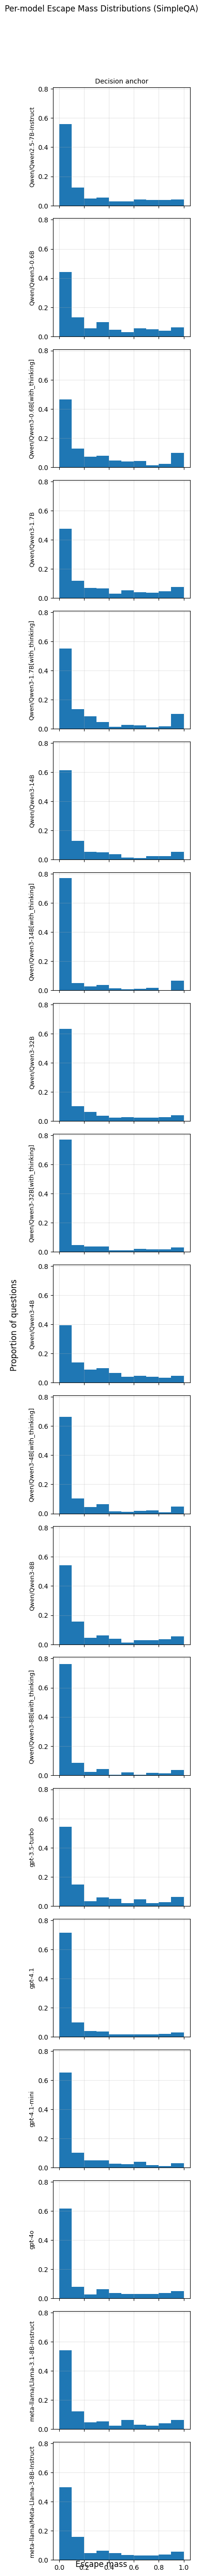

In [29]:
plot_escape_histograms_per_model(aligned)


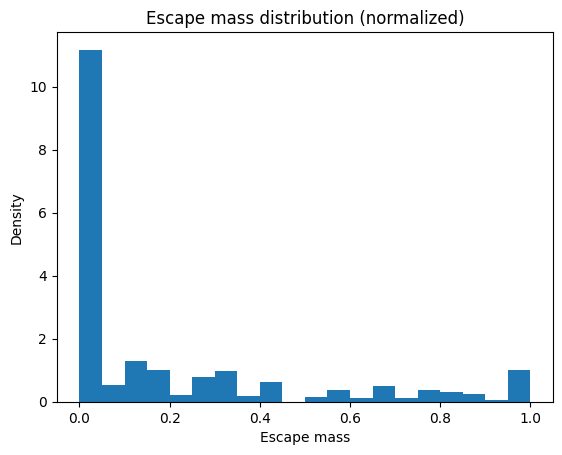

In [30]:
bins = np.linspace(0, 1, 21)
vals = aligned["escape_decision"].dropna().to_numpy()

plt.figure()
plt.hist(vals, bins=bins, density=True)
plt.xlabel("Escape mass")
plt.ylabel("Density")
plt.title("Escape mass distribution (normalized)")
plt.show()


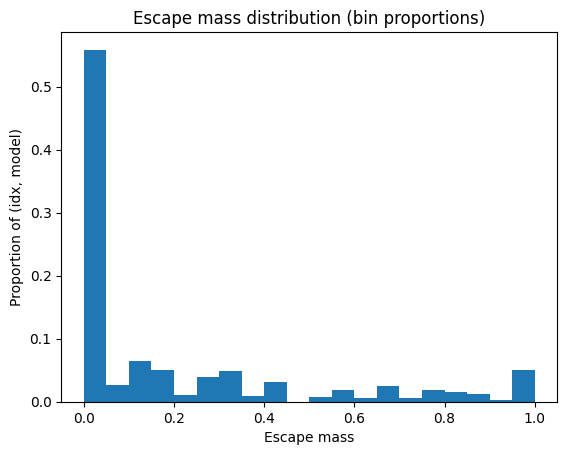

In [31]:
bins = np.linspace(0, 1, 21)
vals = aligned["escape_decision"].dropna().to_numpy()

plt.figure()
plt.hist(vals, bins=bins, weights=np.ones_like(vals) / len(vals))
plt.xlabel("Escape mass")
plt.ylabel("Proportion of (idx, model)")
plt.title("Escape mass distribution (bin proportions)")
plt.show()


In [32]:
import numpy as np

LABELS = ["correct","incorrect","not_attempted"]
P = aligned[[f"{l}_para" for l in LABELS]].copy()

# (A) recompute mode label + mode share from the distribution
mode_label_from_P = P.idxmax(axis=1).str.replace("_para","")
mode_share_from_P = P.max(axis=1)

# compare to your existing fields (optional)
print("para_label matches recomputed mode:",
      (aligned["para_label"] == mode_label_from_P).mean())

# (B) compute anchor share p_anchor = P(para = orig_label)
label_to_col = {l: f"{l}_para" for l in LABELS}
anchor_col = aligned["orig_label"].map(label_to_col)
col_to_i = {c:i for i,c in enumerate(P.columns)}
p_anchor = P.to_numpy()[np.arange(len(P)), anchor_col.map(col_to_i).to_numpy()]

# (C) mismatch implied by distributions: anchor is not a (tied) mode
# If ties exist, anchor could still be "a mode" even if idxmax picks something else.
eps = 1e-12
anchor_is_among_modes = np.abs(p_anchor - mode_share_from_P.to_numpy()) <= eps
mismatch_from_P = ~anchor_is_among_modes

# Compare with your stored mismatch (but ignore tie rows if you want strict equality)
mask_no_tie = ~aligned["para_is_tie"]  # you created this earlier
print("Mismatch equality on non-tie rows:",
      (aligned.loc[mask_no_tie, "match"].to_numpy() == (~mismatch_from_P[mask_no_tie])).mean())

# Also compare rates
print("stored mismatch rate:", (~aligned["match"]).mean())
print("distribution-implied mismatch rate (tie-aware):", mismatch_from_P.mean())


para_label matches recomputed mode: 1.0
Mismatch equality on non-tie rows: 1.0
stored mismatch rate: 0.1530751708428246
distribution-implied mismatch rate (tie-aware): 0.1530751708428246


In [33]:
eps = 1e-12
P = aligned[["correct_para","incorrect_para","not_attempted_para"]]
mode_share = P.max(axis=1).to_numpy()

label_to_col = {"correct":"correct_para", "incorrect":"incorrect_para", "not_attempted":"not_attempted_para"}
anchor_col = aligned["orig_label"].map(label_to_col)

p_anchor = P.to_numpy()[np.arange(len(P)), anchor_col.map({c:i for i,c in enumerate(P.columns)}).to_numpy()]

aligned["mismatch_tieaware"] = (p_anchor + eps) < mode_share
aligned["match_tieaware"] = ~aligned["mismatch_tieaware"]


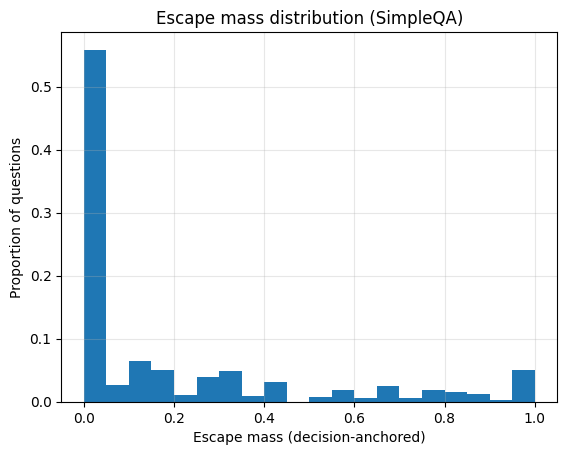

In [34]:
import numpy as np
import matplotlib.pyplot as plt

vals = aligned["escape_decision"].dropna().to_numpy()
bins = np.linspace(0, 1, 21)

plt.figure()
plt.hist(vals, bins=bins, weights=np.ones_like(vals)/len(vals))
plt.xlabel("Escape mass (decision-anchored)")
plt.ylabel("Proportion of questions")
plt.title("Escape mass distribution (SimpleQA)")
plt.grid(True, alpha=0.3)
plt.show()


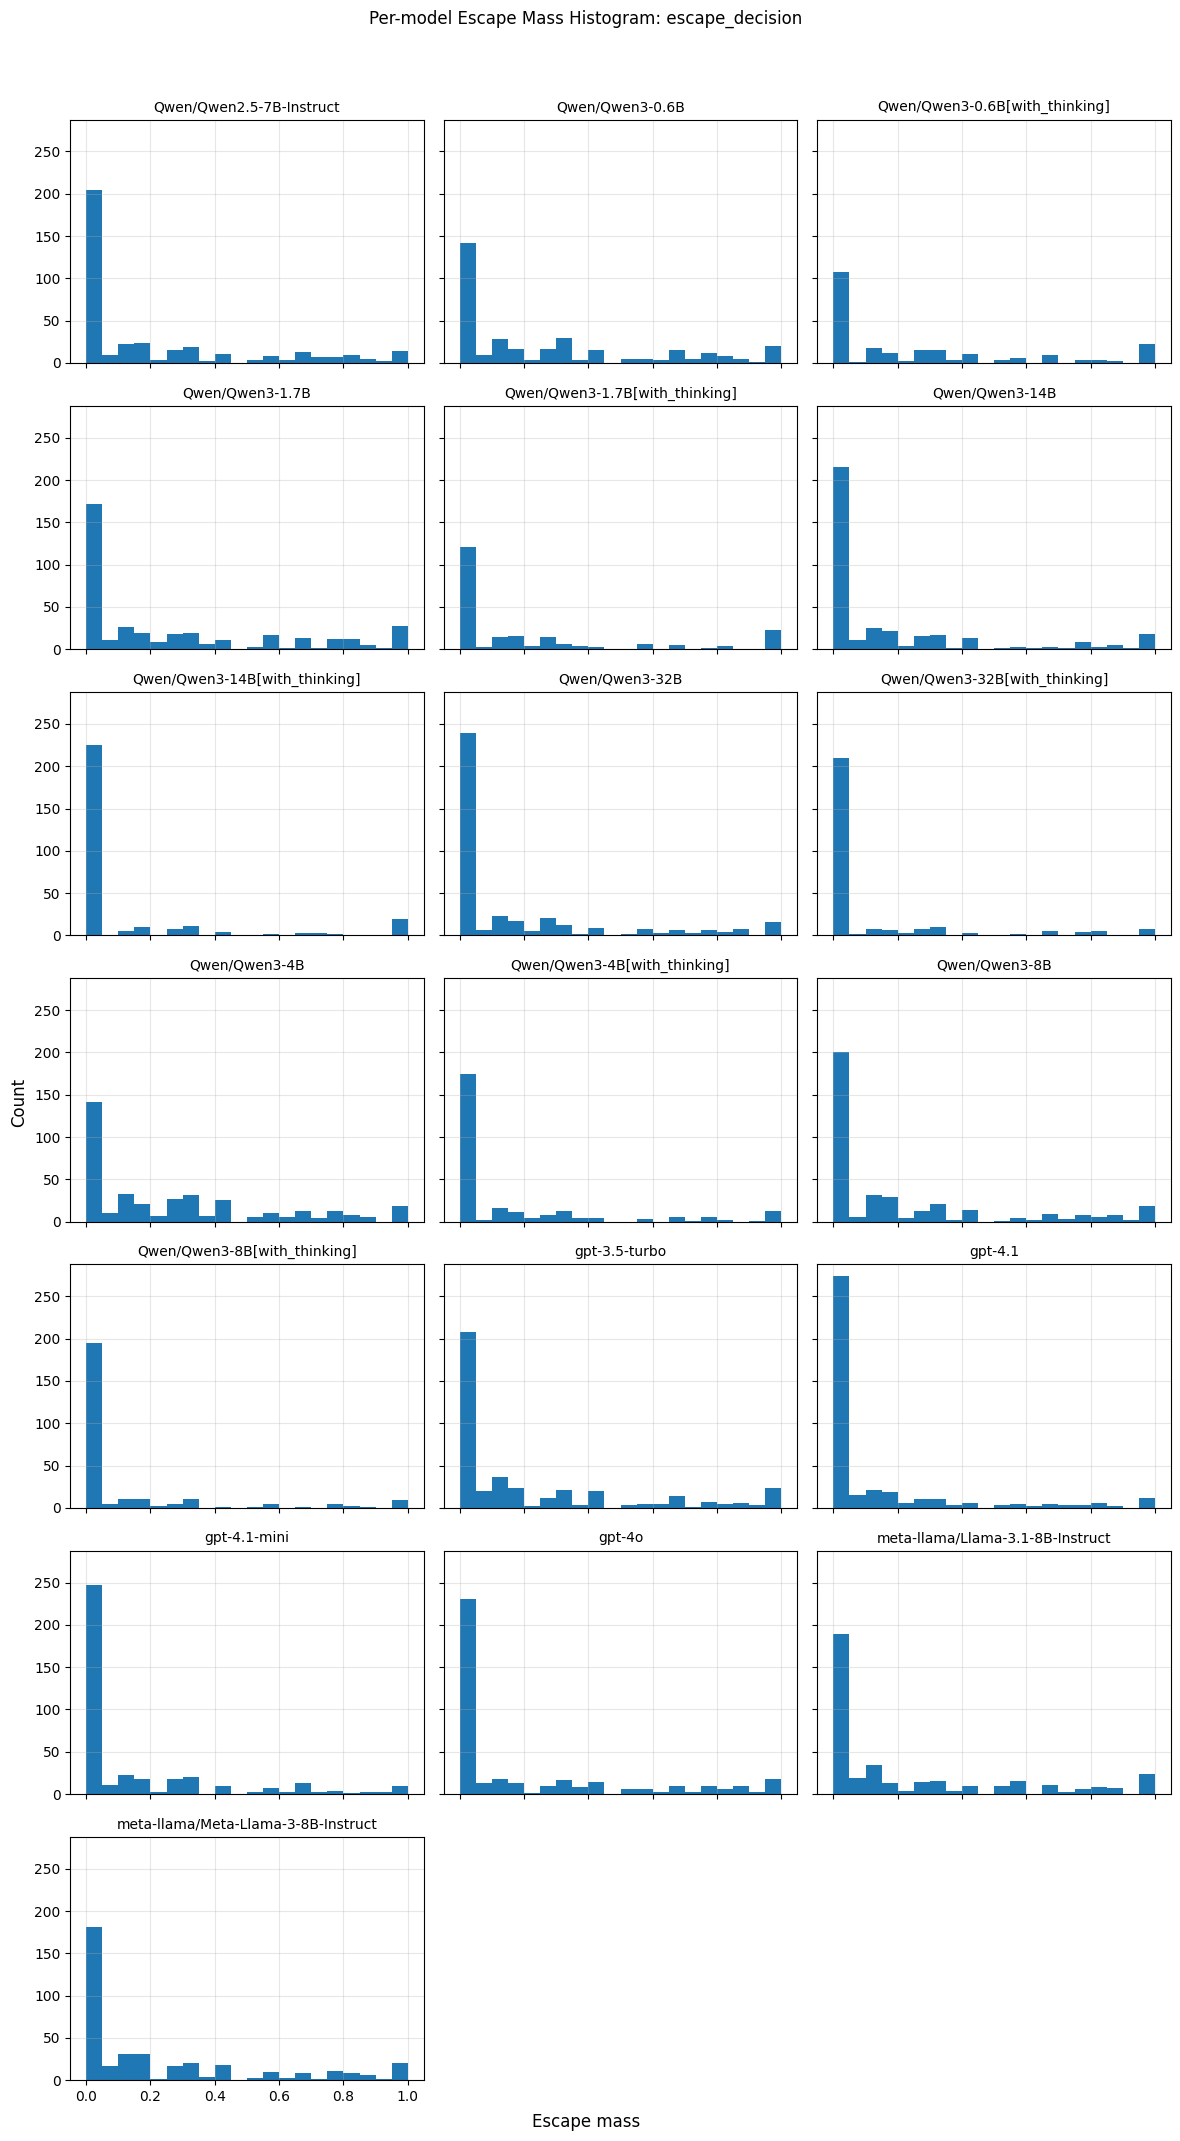

In [35]:
import matplotlib.pyplot as plt
import numpy as np
import math

metric = "escape_decision"   # change to any escape_* column
bins = np.linspace(0, 1, 21)

models = sorted(aligned.reset_index()["model"].unique())

ncols = 3
nrows = math.ceil(len(models) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

df = aligned.reset_index()

for ax, m in zip(axes, models):
    vals = df.loc[df["model"] == m, metric].dropna().to_numpy()
    ax.hist(vals, bins=bins)
    ax.set_title(m, fontsize=10)
    ax.grid(True, alpha=0.3)

for j in range(len(models), len(axes)):
    axes[j].axis("off")

fig.supxlabel("Escape mass")
fig.supylabel("Count")
fig.suptitle(f"Per-model Escape Mass Histogram: {metric}", y=1.02)
plt.tight_layout()
plt.show()


In [36]:
pd.__version__

'2.3.3'

In [37]:
# model_name_map = {
#     "gpt-4.1": "GPT-4.1",
#     "gpt-4o": "GPT-4o",
#     "gpt-4.1-mini": "GPT-4.1-Mini",
#     "gpt-3.5-turbo": "GPT-3.5",
#     "Meta-Llama-3-8B-Instruct": "LLaMA-3 8B",
#     "Llama-3.1-8B-Instruct": "LLaMA-3.1 8B",
#     "Qwen2.5-7B-Instruct": "Qwen-2.5 7B",
#     "Qwen3-8B": "Qwen-3 8B",
#     "gpt-oss-20b": "GPT-OSS 20B",
# }
def shorten_model_name(name):
    return name.split("/")[-1] if "/" in name else name

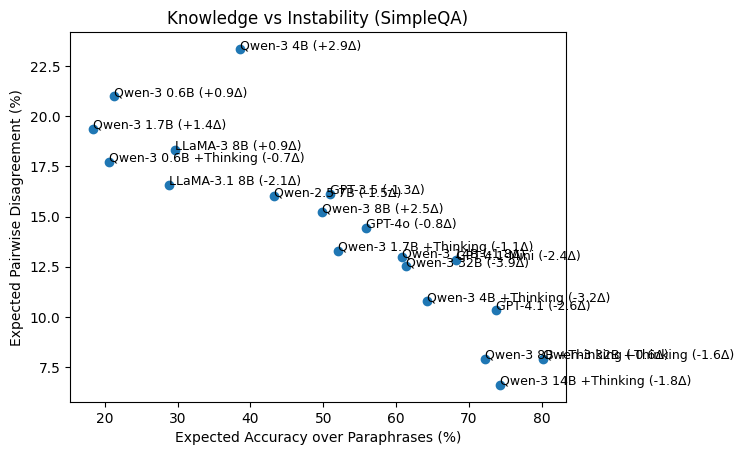

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Build plotting dataframe from your outputs ----
# agg_dist: has correct_orig, correct_para, diffs
# mismatch_stats: has iid_mismatch_prob, normalized_entropy, mismatch_rate, mode_share

plot1 = (
    agg_dist[["correct_orig", "correct_para", "correct_diff"]]
    .join(mismatch_stats[["iid_mismatch_prob", "normalized_entropy", "mismatch_rate", "mode_share"]])
    .reset_index()  # brings "model" out
)
plot1['model'] = plot1['model'].apply(shorten_model_name).replace(model_name_map)
# Convert to % for readability
plot1["orig_acc_pct"] = 100 * plot1["correct_orig"].astype(float)
plot1["para_acc_pct"] = 100 * plot1["correct_para"].astype(float)
plot1["delta_acc_pct"] = 100 * (plot1["correct_para"].astype(float) - plot1["correct_orig"].astype(float))

# Convert instability metric to %
plot1["iid_mismatch_pct"] = 100 * plot1["iid_mismatch_prob"]

y_col = "iid_mismatch_pct"
y_label = "Expected Pairwise Disagreement (%)"

plt.figure()
x = plot1["para_acc_pct"].values
y = plot1[y_col].values

plt.scatter(x, y)

for _, r in plot1.iterrows():
    label = f'{r["model"]} ({r["delta_acc_pct"]:+.1f}Δ)'
    plt.text(r["para_acc_pct"], r[y_col], label, fontsize=9)

plt.xlabel("Expected Accuracy over Paraphrases (%)")
plt.ylabel(y_label)
plt.title("Knowledge vs Instability (SimpleQA)")
plt.show()

# # Choose ONE instability metric for y
# y_col = "iid_mismatch_prob"  # or "normalized_entropy" or "mismatch_rate"
# y_label = "Expected Pairwise Disagreement (IID-Mismatch)"  # adjust if you change y_col

# plt.figure()
# x = plot1["para_acc_pct"].values
# y = plot1[y_col].values

# plt.scatter(x, y)

# # Annotate points with model names
# for _, r in plot1.iterrows():
#     label = f'{r["model"]} ({r["delta_acc_pct"]:+.1f}Δ)'
#     plt.text(r["para_acc_pct"], r[y_col], label, fontsize=9)

# # for _, r in plot1.iterrows():
# #     plt.text(r["para_acc_pct"], r[y_col], r["model"], fontsize=9)

# plt.xlabel("Expected Accuracy over Paraphrases (%)")
# plt.ylabel(y_label)
# plt.title("Knowledge vs Instability (SimpleQA)")

# plt.show()


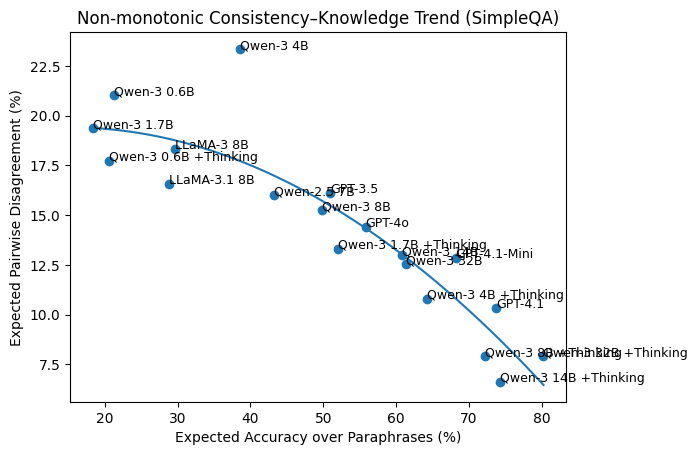

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# x, y from plot1 above
x = plot1["para_acc_pct"].values
y = plot1[y_col].values

plt.figure()
plt.scatter(x, y)
for _, r in plot1.iterrows():
    plt.text(r["para_acc_pct"], r[y_col], r["model"], fontsize=9)

# Quadratic fit: y ≈ ax^2 + bx + c
# NOTE: with only ~7 points, this is illustrative, not a strong statistical claim.
coef = np.polyfit(x, y, deg=2)
xx = np.linspace(x.min(), x.max(), 200)
yy = np.polyval(coef, xx)
plt.plot(xx, yy)

plt.xlabel("Expected Accuracy over Paraphrases (%)")
plt.ylabel(y_label)
plt.title("Non-monotonic Consistency–Knowledge Trend (SimpleQA)")
plt.show()


/tmp/ipykernel_2803875/249717193.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  curve = df_q.groupby("acc_bin")[y_qcol].mean().reset_index()


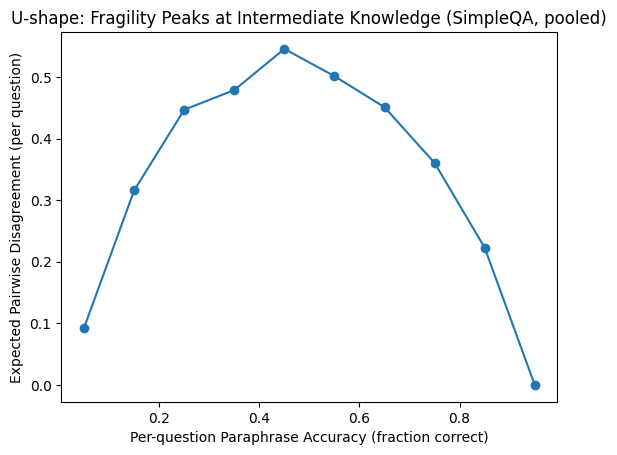

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# For each question (row), we need:
# x_i: correctness fraction over paraphrases (0..1)
# y_i: instability for that question (entropy or pairwise mismatch prob)
# aligned seems to have normalized_entropy, iid_mismatch_prob per row.

df_q = aligned.reset_index()[["model", "correct_para", "iid_mismatch_prob", "normalized_entropy"]].copy()

# Choose which y to use
y_qcol = "iid_mismatch_prob"
y_qlabel = "Expected Pairwise Disagreement (per question)"

# Bin x into deciles
bins = np.linspace(0, 1, 11)
df_q["acc_bin"] = pd.cut(df_q["correct_para"].astype(float), bins=bins, include_lowest=True)

# Aggregate within bins (option 1: across all models)
curve = df_q.groupby("acc_bin")[y_qcol].mean().reset_index()
curve["bin_center"] = curve["acc_bin"].apply(lambda x: (x.left + x.right) / 2)

plt.figure()
plt.plot(curve["bin_center"], curve[y_qcol], marker="o")
plt.xlabel("Per-question Paraphrase Accuracy (fraction correct)")
plt.ylabel(y_qlabel)
plt.title("U-shape: Fragility Peaks at Intermediate Knowledge (SimpleQA, pooled)")
plt.show()


/tmp/ipykernel_2803875/1630434884.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sub.groupby("acc_bin")[y_qcol]
/tmp/ipykernel_2803875/1630434884.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sub.groupby("acc_bin")[y_qcol]
/tmp/ipykernel_2803875/1630434884.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sub.groupby("acc_bin")[y_qcol]
/tmp/ipykernel_2803875/1630434884.py:27: FutureWarning: The default of

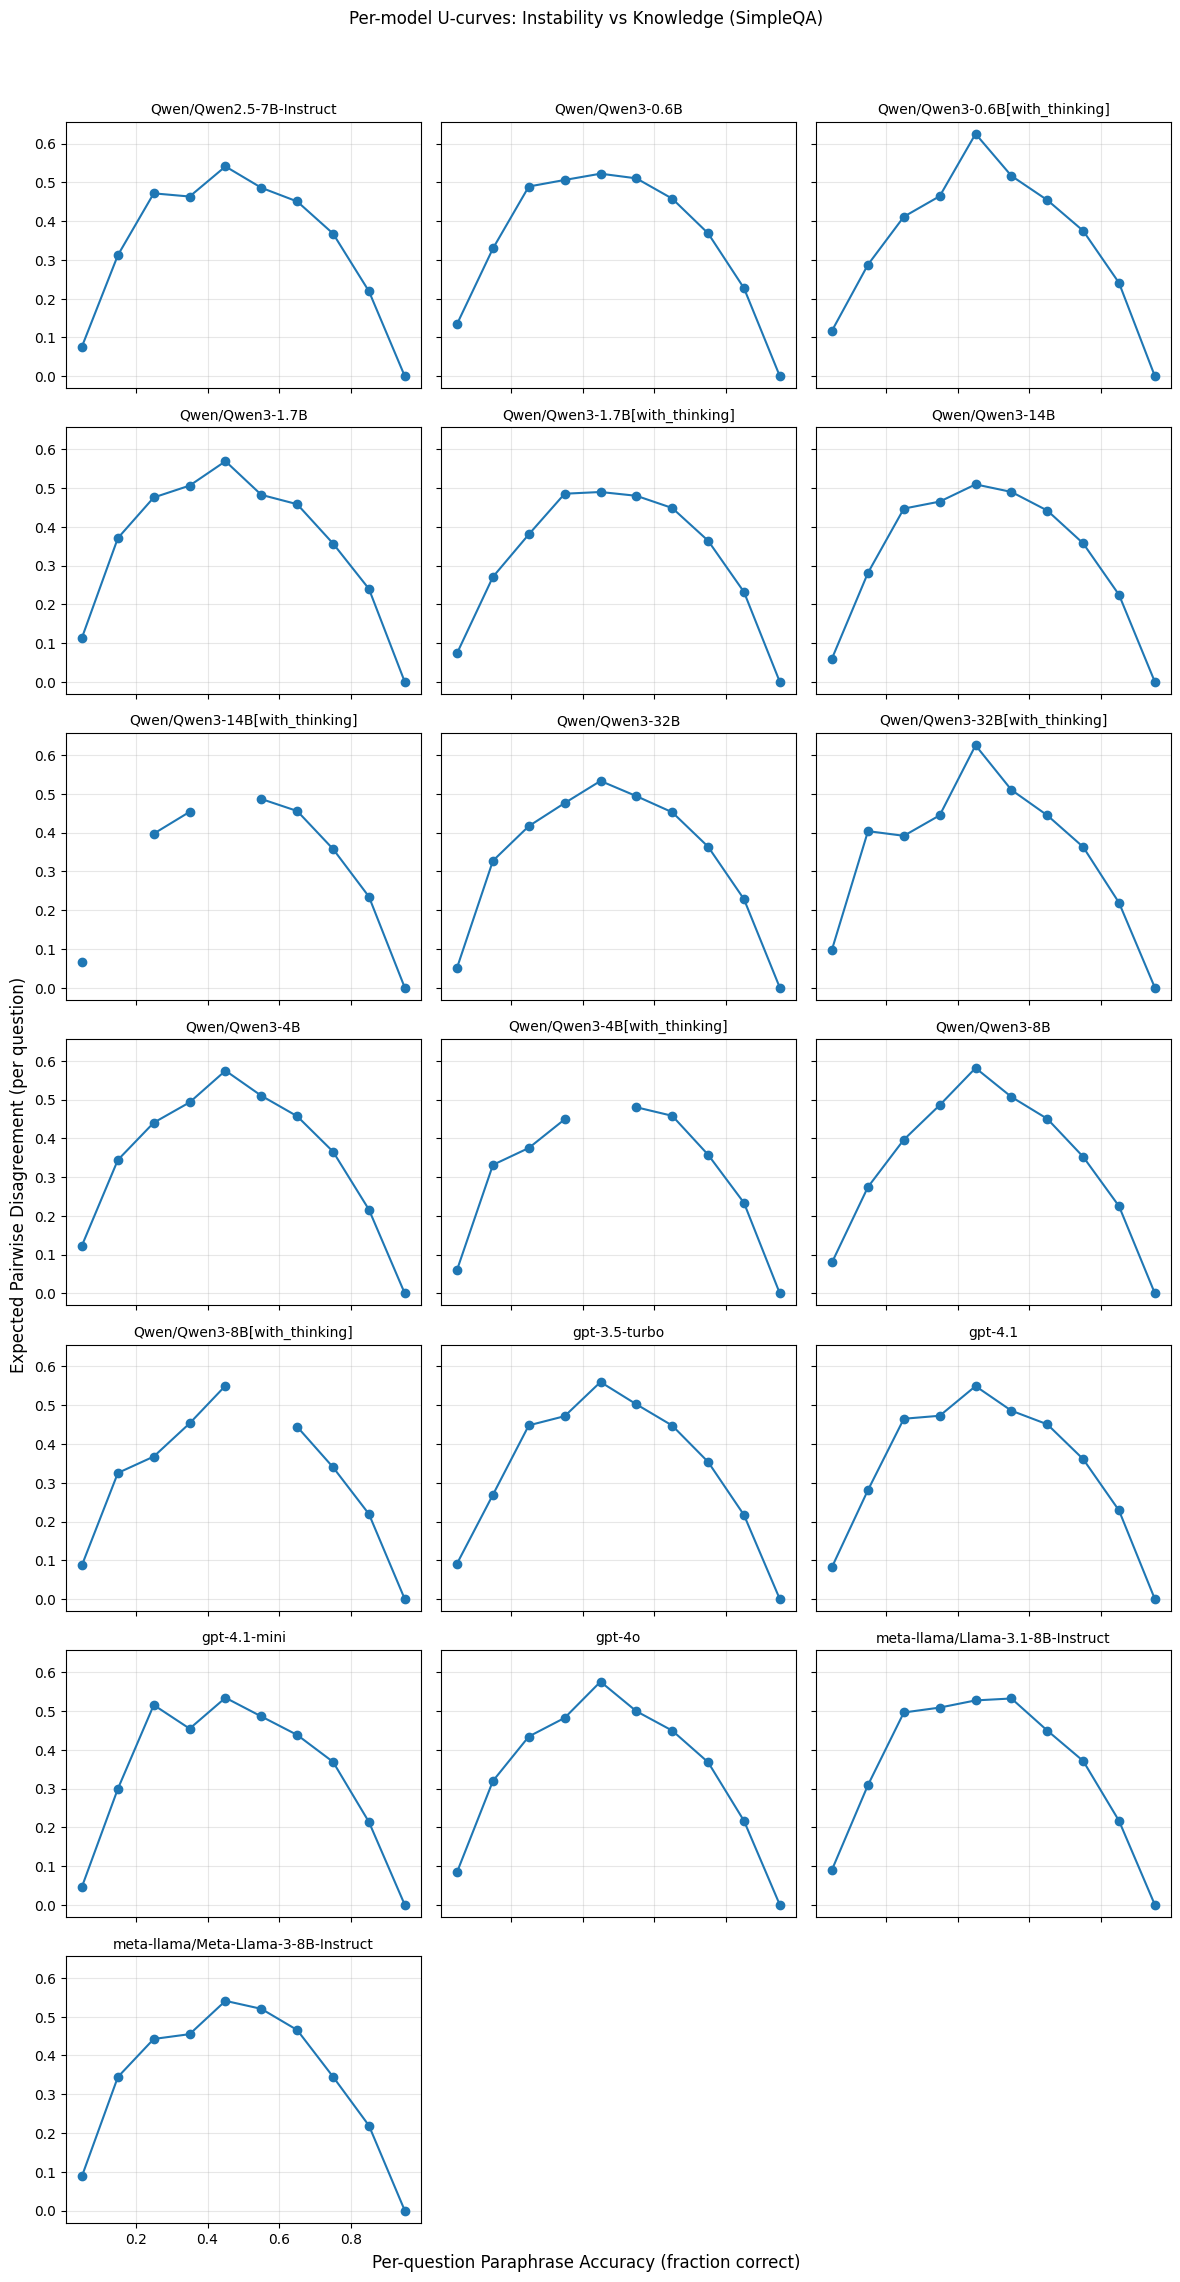

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

df_q = aligned.reset_index()[["model", "correct_para", "iid_mismatch_prob", "normalized_entropy"]].copy()

y_qcol = "iid_mismatch_prob"
y_qlabel = "Expected Pairwise Disagreement (per question)"

bins = np.linspace(0, 1, 11)
df_q["acc_bin"] = pd.cut(df_q["correct_para"].astype(float), bins=bins, include_lowest=True)

models = sorted(df_q["model"].unique())

n = len(models)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3.2*nrows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

for ax, m in zip(axes, models):
    sub = df_q[df_q["model"] == m]

    curve = (
        sub.groupby("acc_bin")[y_qcol]
           .mean()
           .reset_index()
    )
    curve["bin_center"] = curve["acc_bin"].apply(lambda x: (x.left + x.right) / 2)

    ax.plot(curve["bin_center"], curve[y_qcol], marker="o")
    ax.set_title(m, fontsize=10)
    ax.grid(True, alpha=0.3)

# Hide unused axes
for j in range(len(models), len(axes)):
    axes[j].axis("off")

fig.supxlabel("Per-question Paraphrase Accuracy (fraction correct)")
fig.supylabel(y_qlabel)
fig.suptitle("Per-model U-curves: Instability vs Knowledge (SimpleQA)", y=1.02)
plt.tight_layout()
plt.show()


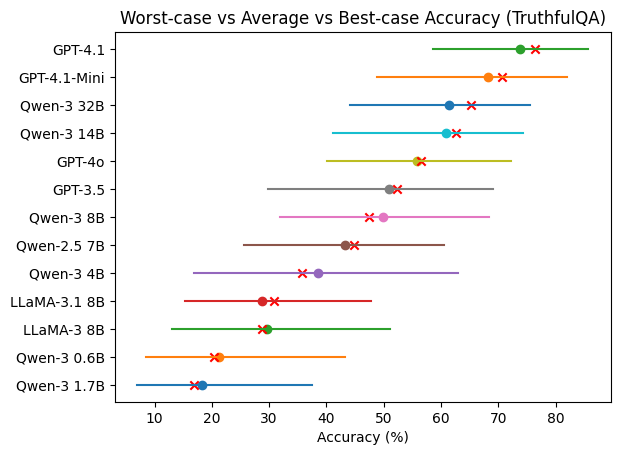

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# df_Aany has:
# Orig_Acc, Para_Acc, A_any_all, reliable_A (all already in %)
temp = df_Aany.copy()
temp['model'] = temp['model'].replace(model_name_map)
temp = temp[(~temp['model'].str.lower().str.contains('thinking')) & (~temp['model'].str.lower().str.contains('gpt-oss'))]
plot3 = temp.sort_values("Para_Acc", ascending=True).copy()
plot3 = plot3.sort_values("Orig_Acc", ascending=True)  # nicer for horizontal plotting

models = plot3["model"].tolist()
y = np.arange(len(models))

reliable = plot3["reliable_A"].values
expected = plot3["Para_Acc"].values
original = plot3["Orig_Acc"].values
bestcase = plot3["A_any_all"].values

plt.figure()
# Draw horizontal intervals from reliable -> bestcase
for i in range(len(models)):
    plt.plot([reliable[i], bestcase[i]], [y[i], y[i]])
    plt.scatter([expected[i]], [y[i]])  # dot at expected
    plt.scatter([original[i]], [y[i]], marker="x", color="red")  # x at original

plt.yticks(y, models)
plt.xlabel("Accuracy (%)")
plt.title("Worst-case vs Average vs Best-case Accuracy (TruthfulQA)")
plt.show()


['GPT-4.1', 'GPT-4.1-Mini', 'Qwen-3 32B', 'Qwen-3 14B', 'GPT-4o', 'GPT-3.5', 'Qwen-3 8B', 'Qwen-2.5 7B', 'Qwen-3 4B', 'LLaMA-3.1 8B', 'LLaMA-3 8B', 'Qwen-3 0.6B', 'Qwen-3 1.7B']


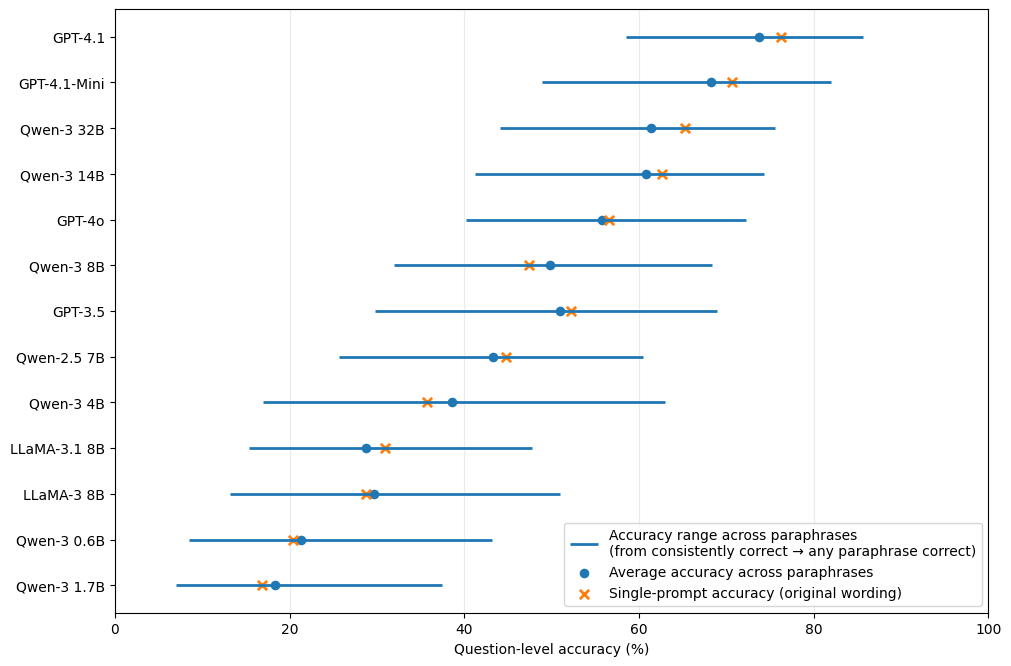

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# df_Aany has (all in %):
# Orig_Acc        → accuracy on original wording
# Para_Acc        → average accuracy across paraphrases
# reliable_A      → accuracy on consistently answered questions
# A_any_all       → best-case accuracy (any paraphrase correct)

temp = df_Aany.copy()
temp["model"] = temp["model"].replace(model_name_map)
temp = temp[
    (~temp["model"].str.lower().str.contains("thinking")) &
    (~temp["model"].str.lower().str.contains("gpt-oss"))
]
print(temp.model.tolist())

# Sort by worst / most conservative behavior for readability
plot3 = temp.sort_values("reliable_A", ascending=True)

models = plot3["model"].tolist()
y = np.arange(len(models))

# Reader-facing quantities
acc_consistent = plot3["reliable_A"].values
acc_best_case  = plot3["A_any_all"].values
acc_paraphrase = plot3["Para_Acc"].values
acc_single     = plot3["Orig_Acc"].values

fig, ax = plt.subplots(
    figsize=(10, 0.35 * len(models) + 2),
    constrained_layout=True
)

# Accuracy range across paraphrases
ax.hlines(
    y=y,
    xmin=acc_consistent,
    xmax=acc_best_case,
    linewidth=2,
    label=(
        "Accuracy range across paraphrases\n"
        "(from consistently correct → any paraphrase correct)"
    )
)

# Average across paraphrases
ax.scatter(
    acc_paraphrase,
    y,
    s=35,
    label="Average accuracy across paraphrases"
)

# Original wording (single prompt)
ax.scatter(
    acc_single,
    y,
    s=45,
    marker="x",
    linewidths=2,
    label="Single-prompt accuracy (original wording)"
)

ax.set_yticks(y)
ax.set_yticklabels(models)
ax.set_xlim(0, 100)
ax.grid(axis="x", alpha=0.25)

ax.set_xlabel("Question-level accuracy (%)")
# ax.set_title("Accuracy Varies Widely Across Meaning-Preserving Paraphrases")
# ax.set_title(
#     f"Accuracy Varies Widely Across Meaning-Preserving Paraphrases ({dataset})"
# )

ax.legend(loc="lower right", frameon=True)

fig.savefig(
    f"accuracy_paraphrase_range_{dataset.lower()}.pdf",
    bbox_inches="tight"
)
plt.show()


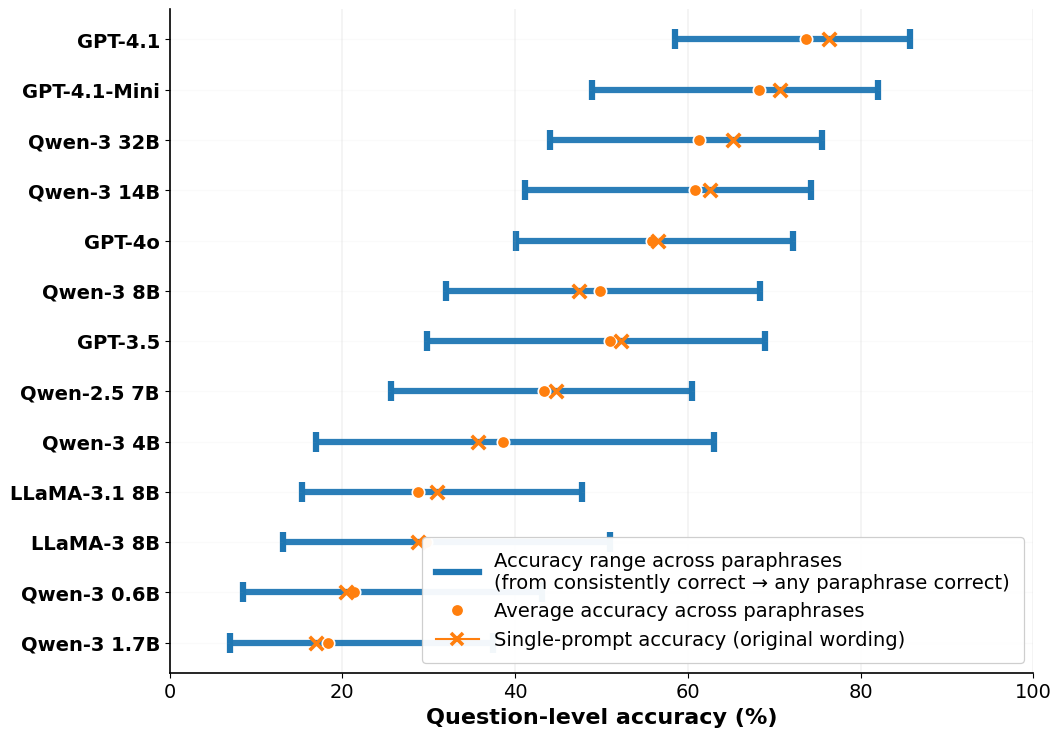

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# df_Aany has (all in %):
# Orig_Acc        → accuracy on original wording
# Para_Acc        → average accuracy across paraphrases
# reliable_A      → accuracy on consistently answered questions
# A_any_all       → best-case accuracy (any paraphrase correct)

# ---------- styling for paper ----------
# plt.rcParams.update({
#     "font.size": 12,
#     "axes.titlesize": 15,
#     "axes.titleweight": "bold",
#     "axes.labelsize": 13,
#     "axes.labelweight": "bold",
#     "xtick.labelsize": 12,
#     "ytick.labelsize": 12,
#     "legend.fontsize": 11,
# })
plt.rcParams.update({
    "font.size": 15,          # base size
    "axes.titlesize": 18,
    "axes.titleweight": "bold",
    "axes.labelsize": 16,
    "axes.labelweight": "bold",
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})


RANGE_LW = 4.5
CAP_MS   = 14   # size of end-caps
DOT_S    = 80   # avg marker area
X_S      = 95   # orig marker area
X_LW     = 2.6  # orig marker stroke

temp = df_Aany.copy()
temp["model"] = temp["model"].replace(model_name_map)
temp = temp[
    (~temp["model"].str.lower().str.contains("thinking")) &
    (~temp["model"].str.lower().str.contains("gpt-oss"))
]

# Sort by worst / most conservative behavior for readability
plot3 = temp.sort_values("reliable_A", ascending=True)

models = plot3["model"].tolist()
y = np.arange(len(models))

acc_consistent = plot3["reliable_A"].values
acc_best_case  = plot3["A_any_all"].values
acc_paraphrase = plot3["Para_Acc"].values
acc_single     = plot3["Orig_Acc"].values

fig, ax = plt.subplots(
    figsize=(10.5, 0.42 * len(models) + 1.8),
    constrained_layout=True
)

# --- Range (consistent -> any paraphrase correct): thick + rounded + capped ---
range_color = "#1f77b4"
ax.hlines(
    y=y,
    xmin=acc_consistent,
    xmax=acc_best_case,
    linewidth=RANGE_LW,
    color=range_color,
    alpha=0.95,
)
# end-caps (visible “I”-style caps)
ax.scatter(acc_consistent, y, marker="|", s=CAP_MS**2, color=range_color, linewidths=RANGE_LW)
ax.scatter(acc_best_case,  y, marker="|", s=CAP_MS**2, color=range_color, linewidths=RANGE_LW)

# --- Average across paraphrases (bold dot) ---
avg_color = "#ff7f0e"
ax.scatter(
    acc_paraphrase, y,
    s=DOT_S,
    marker="o",
    color=avg_color,
    edgecolor="white",
    linewidth=1.2,
    zorder=3,
)

# --- Single prompt original (bold X) ---
ax.scatter(
    acc_single, y,
    s=X_S,
    marker="x",
    color=avg_color,
    linewidths=X_LW,
    zorder=4,
)

# Axes / labels
ax.set_yticks(y)
ax.set_yticklabels(models, fontweight="bold")
ax.set_xlim(0, 100)

ax.set_xlabel("Question-level accuracy (%)")

# ax.set_title(f"Accuracy Varies Widely Across Meaning-Preserving Paraphrases ({dataset})")

# Grid + spines (cleaner)
ax.grid(axis="x", alpha=0.18, linewidth=1.1)
ax.grid(axis="y", alpha=0.06, linewidth=0.8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)

# Legend with custom handles (so it matches the plot style)
handles = [
    Line2D([0], [0], color=range_color, lw=RANGE_LW,
           label="Accuracy range across paraphrases\n(from consistently correct → any paraphrase correct)"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor=avg_color,
           markeredgecolor="white", markeredgewidth=1.2, markersize=9,
           label="Average accuracy across paraphrases"),
    Line2D([0], [0], marker="x", color=avg_color, markersize=9, markeredgewidth=X_LW,
           label="Single-prompt accuracy (original wording)"),
]
leg = ax.legend(
    handles=handles,
    loc="lower right",
    frameon=True,
    fancybox=True,
    framealpha=0.95,
    borderpad=0.7,
    handlelength=2.2,
)
leg.get_frame().set_linewidth(0.9)

fig.savefig(
    f"accuracy_paraphrase_range_{dataset.lower()}.pdf",
    bbox_inches="tight"
)
plt.show()


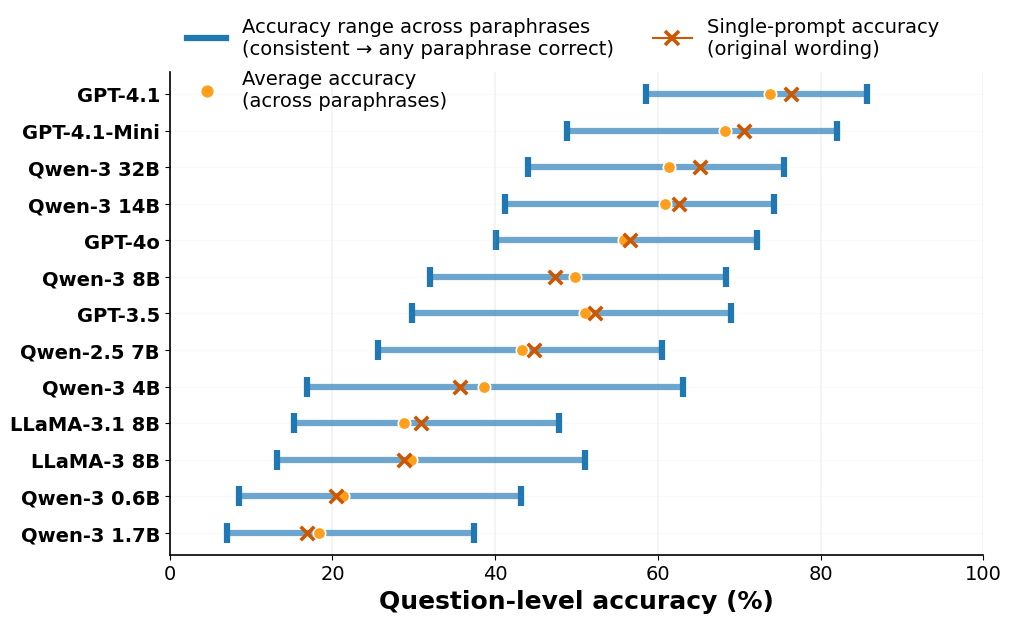

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ---------- styling for paper ----------
plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 18,
    "axes.titleweight": "bold",
    "axes.labelsize": 18,
    "axes.labelweight": "bold",
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})

RANGE_LW = 4.5
CAP_MS   = 14
DOT_S    = 80
X_S      = 95
X_LW     = 2.6

# ---------- data ----------
temp = df_Aany.copy()
temp["model"] = temp["model"].replace(model_name_map)
temp = temp[
    (~temp["model"].str.lower().str.contains("thinking")) &
    (~temp["model"].str.lower().str.contains("gpt-oss"))
]

plot3 = temp.sort_values("reliable_A", ascending=True)

models = plot3["model"].tolist()
y = np.arange(len(models))

acc_consistent = plot3["reliable_A"].values
acc_best_case  = plot3["A_any_all"].values
acc_paraphrase = plot3["Para_Acc"].values
acc_single     = plot3["Orig_Acc"].values

# ---------- figure (NO constrained_layout) ----------
fig, ax = plt.subplots(
    figsize=(10.5, 0.37 * len(models) + 1.8)
)

# Reserve vertical space ONLY for the top legend
# This does NOT change plot width or aspect
fig.subplots_adjust(top=0.84)   # tune 0.82–0.88 if needed

# ---------- plot ----------
range_color = "#1f77b4"
avg_color   = "#ff7f0e"
avg_dot_color   = "#ff7f0e"   # orange
orig_cross_color = "#d95f02" # darker orange
avg_dot_color    = "#ff9f1c"   # lighter, vivid orange
orig_cross_color = "#cc5803"   # darker, burnt orange


# Range: consistently correct → any paraphrase correct
ax.hlines(
    y=y,
    xmin=acc_consistent,
    xmax=acc_best_case,
    linewidth=RANGE_LW,
    color=range_color,
    alpha=0.65,
)
ax.scatter(acc_consistent, y, marker="|", s=CAP_MS**2,
           color=range_color, linewidths=RANGE_LW)
ax.scatter(acc_best_case,  y, marker="|", s=CAP_MS**2,
           color=range_color, linewidths=RANGE_LW)

# Average across paraphrases
ax.scatter(
    acc_paraphrase, y,
    s=DOT_S,
    marker="o",
    color=avg_dot_color,
    edgecolor="white",
    linewidth=1.2,
    zorder=3,
)

# Single-prompt accuracy
ax.scatter(
    acc_single, y,
    s=X_S,
    marker="x",
    color=orig_cross_color,
    linewidths=X_LW,
    zorder=4,
)

# ---------- axes ----------
ax.set_yticks(y)
ax.set_yticklabels(models, fontweight="bold")
ax.set_xlim(0, 100)
ax.set_xlabel("Question-level accuracy (%)")

ax.grid(axis="x", alpha=0.18, linewidth=1.1)
ax.grid(axis="y", alpha=0.06, linewidth=0.8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)

# ---------- legend (FIGURE-LEVEL, ON TOP) ----------
handles = [
    Line2D([0], [0], color=range_color, lw=RANGE_LW,
           label="Accuracy range across paraphrases\n(from consistently correct → any paraphrase correct)"),
    Line2D([0], [0], marker="o", color="none",
           markerfacecolor=avg_color,
           markeredgecolor="white",
           markeredgewidth=1.2,
           markersize=10,
           label="Average accuracy across paraphrases"),
    Line2D([0], [0], marker="x", color=avg_color,
           markersize=10,
           markeredgewidth=X_LW,
           label="Single-prompt accuracy (original wording)"),
]
handles = [
    Line2D([0], [0], color=range_color, lw=RANGE_LW,
           label="Accuracy range across paraphrases\n(consistent → any paraphrase correct)"),
    Line2D([0], [0], marker="o", color="none",
           markerfacecolor=avg_dot_color, markeredgecolor="white",
           markeredgewidth=1.2, markersize=10,
           label="Average accuracy\n(across paraphrases)"),
    Line2D([0], [0], marker="x", color=orig_cross_color,
           markersize=10, markeredgewidth=X_LW,
           label="Single-prompt accuracy\n(original wording)"),
]

# fig.legend(
#     handles=handles,
#     loc="upper center",
#     bbox_to_anchor=(0.5, 0.98),
#     ncol=2,                # stacked → tall & slim
#     frameon=True,
#     fancybox=True,
#     framealpha=0.45,
#     handlelength=1.8,
#     handletextpad=0.6,
#     labelspacing=0.4,
# )
fig.legend(
    handles=handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.95),
    ncol=2,
    frameon=True,
    framealpha=0.0,
    columnspacing=2.0,   # key
    handlelength=2.0,
    labelspacing=0.6,
)

# ax.legend(
#     handles=handles,
#     loc="upper left",
#     frameon=True,
#     fancybox=True,
#     framealpha=0.2,   # transparency (0 = fully transparent, 1 = solid)
#     handlelength=1.8,
#     handletextpad=0.6,
#     labelspacing=0.4,
# )

# ---------- save ----------
fig.savefig(
    f"accuracy_paraphrase_range_{dataset.lower()}.pdf",
    bbox_inches="tight"
)

plt.show()


In [46]:
import matplotlib as mpl

mpl.rcParams.update(mpl.rcParamsDefault)


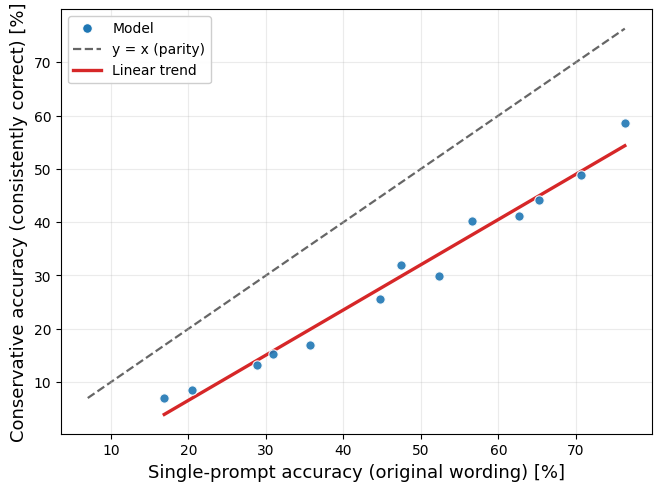

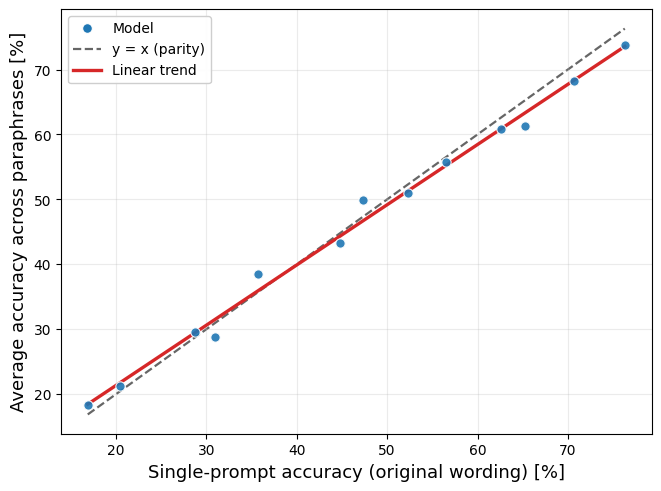

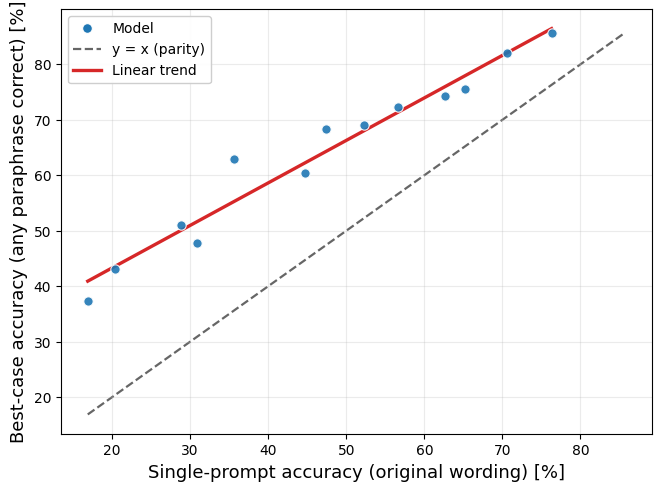

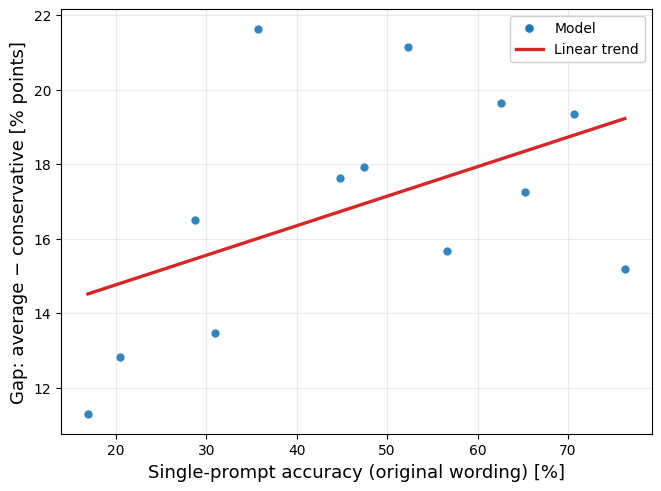

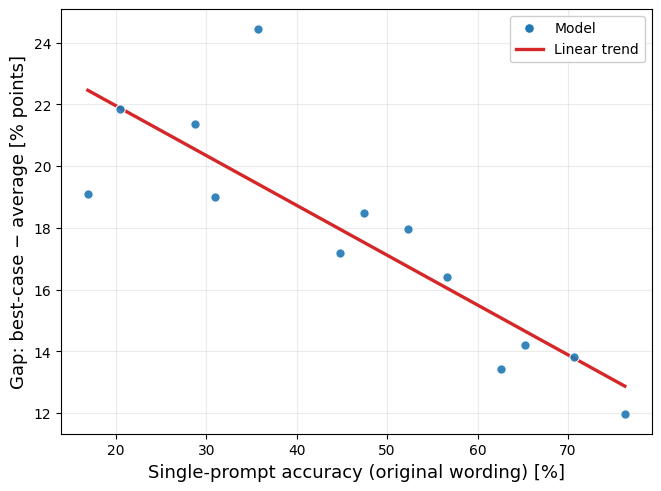

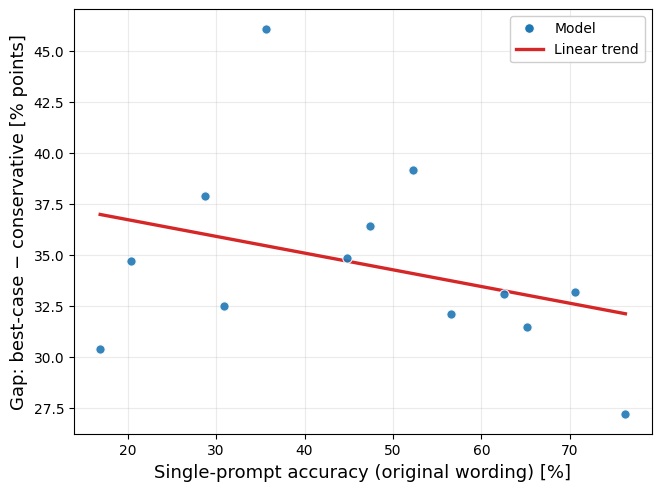

In [47]:
import numpy as np
import matplotlib.pyplot as plt

# Assumes you already have plot3 from your code.
# plot3 columns: Orig_Acc, Para_Acc, reliable_A, A_any_all, model
# plt.rcParams.update({
#     "font.size": 12,
#     "axes.titlesize": 15,
#     "axes.titleweight": "bold",
#     "axes.labelsize": 13,
#     "axes.labelweight": "bold",
#     "xtick.labelsize": 10,
#     "ytick.labelsize": 10,
#     "legend.fontsize": 11,
# })
df = plot3.copy()

# Reader-facing derived metrics
df["Conservative_Acc"] = df["reliable_A"]      # "consistently correct" accuracy
df["Average_Acc"]      = df["Para_Acc"]        # mean across paraphrases
df["BestCase_Acc"]     = df["A_any_all"]       # any paraphrase correct

df["Gap_AvgMinusCons"] = df["Average_Acc"] - df["Conservative_Acc"]
df["Gap_BestMinusAvg"] = df["BestCase_Acc"] - df["Average_Acc"]
df["Gap_BestMinusCons"]= df["BestCase_Acc"] - df["Conservative_Acc"]

x = df["Orig_Acc"].to_numpy()
models = df["model"].to_numpy()

# def _scatter_with_refs(x, y, xlabel, ylabel, title, outpath=None, add_y_eq_x=True, add_trend=True):
#     fig, ax = plt.subplots(figsize=(6.5, 4.8), constrained_layout=True)
#     ax.scatter(x, y, s=35)

#     # y=x reference (only meaningful when x and y share same scale)
#     if add_y_eq_x:
#         lo = min(np.nanmin(x), np.nanmin(y))
#         hi = max(np.nanmax(x), np.nanmax(y))
#         ax.plot([lo, hi], [lo, hi], linewidth=1)

#     # simple linear trend line
#     if add_trend:
#         mask = np.isfinite(x) & np.isfinite(y)
#         if mask.sum() >= 2:
#             m, b = np.polyfit(x[mask], y[mask], 1)
#             xx = np.linspace(np.nanmin(x), np.nanmax(x), 200)
#             ax.plot(xx, m * xx + b, linewidth=2)

#     ax.grid(alpha=0.25)
#     # ax.tick_params(axis="x", labelsize=14)
#     # ax.tick_params(axis="y", labelsize=14)

#     ax.set_xlabel(xlabel, fontsize=13)
#     ax.set_ylabel(ylabel, fontsize=13)
#     ax.set_xlabel(xlabel)
#     ax.set_ylabel(ylabel)
#     # ax.set_title(title)

#     if outpath is not None:
#         fig.savefig(outpath, bbox_inches="tight")
#     plt.show()

from matplotlib.lines import Line2D

def _scatter_with_refs(
    x, y, xlabel, ylabel, title,
    outpath=None,
    add_y_eq_x=True,
    add_trend=True,
):
    fig, ax = plt.subplots(figsize=(6.5, 4.8), constrained_layout=True)

    # --- COLORS (intentional & consistent) ---
    point_color = "#1f77b4"   # blue: models
    trend_color = "#d62728"   # red: trend
    ref_color   = "0.4"       # gray: y=x

    # --- Scatter: models ---
    ax.scatter(
        x, y,
        s=45,
        color=point_color,
        alpha=0.9,
        edgecolor="white",
        linewidth=0.8,
        zorder=3,
    )

    legend_handles = [
        Line2D([0], [0], marker="o", color="none",
               markerfacecolor=point_color,
               markeredgecolor="white",
               markeredgewidth=0.8,
               markersize=7,
               label="Model")
    ]

    # --- y = x reference ---
    if add_y_eq_x:
        lo = min(np.nanmin(x), np.nanmin(y))
        hi = max(np.nanmax(x), np.nanmax(y))
        ax.plot(
            [lo, hi], [lo, hi],
            linestyle="--",
            color=ref_color,
            linewidth=1.6,
            zorder=1,
        )
        legend_handles.append(
            Line2D([0], [0], linestyle="--", color=ref_color,
                   linewidth=1.6, label="y = x (parity)")
        )

    # --- Linear trend ---
    if add_trend:
        mask = np.isfinite(x) & np.isfinite(y)
        if mask.sum() >= 2:
            m, b = np.polyfit(x[mask], y[mask], 1)
            xx = np.linspace(np.nanmin(x), np.nanmax(x), 200)
            ax.plot(
                xx, m * xx + b,
                color=trend_color,
                linewidth=2.4,
                zorder=2,
            )
            legend_handles.append(
                Line2D([0], [0], color=trend_color,
                       linewidth=2.4, label="Linear trend")
            )

    # --- Axes & grid ---
    ax.grid(alpha=0.25)
    ax.set_xlabel(xlabel, fontsize=13)
    ax.set_ylabel(ylabel, fontsize=13)

    # --- Legend ---
    ax.legend(
        handles=legend_handles,
        frameon=True,
        fancybox=True,
        framealpha=0.95,
        loc="best",
    )

    if outpath is not None:
        fig.savefig(outpath, bbox_inches="tight")
    plt.show()


# --- 1) Original vs min/avg/max (same units → y=x line makes sense) ---
_scatter_with_refs(
    x, df["Conservative_Acc"].to_numpy(),
    xlabel="Single-prompt accuracy (original wording) [%]",
    ylabel="Conservative accuracy (consistently correct) [%]",
    title=f"{dataset}: Original vs Conservative Accuracy",
    outpath=f"orig_vs_conservative_{dataset}.pdf",
    add_y_eq_x=True
)

_scatter_with_refs(
    x, df["Average_Acc"].to_numpy(),
    xlabel="Single-prompt accuracy (original wording) [%]",
    ylabel="Average accuracy across paraphrases [%]",
    title=f"{dataset}: Original vs Average Paraphrase Accuracy",
    outpath=f"orig_vs_average_{dataset}.pdf",
    add_y_eq_x=True
)

_scatter_with_refs(
    x, df["BestCase_Acc"].to_numpy(),
    xlabel="Single-prompt accuracy (original wording) [%]",
    ylabel="Best-case accuracy (any paraphrase correct) [%]",
    title=f"{dataset}: Original vs Best-Case Accuracy",
    outpath=f"orig_vs_bestcase_{dataset}.pdf",
    add_y_eq_x=True
)


# --- 2) Original vs gaps (gaps are different units/scale → no y=x line) ---
_scatter_with_refs(
    x, df["Gap_AvgMinusCons"].to_numpy(),
    xlabel="Single-prompt accuracy (original wording) [%]",
    ylabel="Gap: average − conservative [% points]",
    title=f"{dataset}: Original Accuracy vs (Average − Conservative) Gap",
    outpath=f"orig_vs_gap_avg_minus_cons_{dataset}.pdf",
    add_y_eq_x=False
)

_scatter_with_refs(
    x, df["Gap_BestMinusAvg"].to_numpy(),
    xlabel="Single-prompt accuracy (original wording) [%]",
    ylabel="Gap: best-case − average [% points]",
    title=f"{dataset}: Original Accuracy vs (Best-Case − Average) Gap",
    outpath=f"orig_vs_gap_best_minus_avg_{dataset}.pdf",
    add_y_eq_x=False
)

_scatter_with_refs(
    x, df["Gap_BestMinusCons"].to_numpy(),
    xlabel="Single-prompt accuracy (original wording) [%]",
    ylabel="Gap: best-case − conservative [% points]",
    title=f"{dataset}: Original Accuracy vs (Best-Case − Conservative) Gap",
    outpath=f"orig_vs_gap_best_minus_cons_{dataset}.pdf",
    add_y_eq_x=False
)


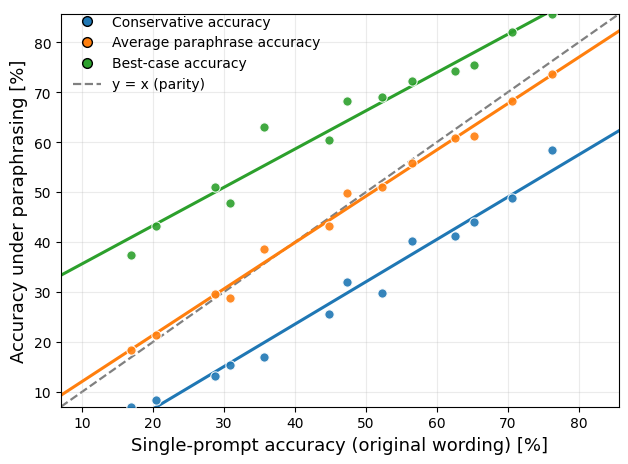

In [48]:
from matplotlib.lines import Line2D
import numpy as np
import matplotlib.pyplot as plt

# --- Data ---
df = plot3.copy()
df["Conservative_Acc"] = df["reliable_A"]      # "consistently correct" accuracy
df["Average_Acc"]      = df["Para_Acc"]        # mean across paraphrases
df["BestCase_Acc"]     = df["A_any_all"]       # any paraphrase correct
x = df["Orig_Acc"].to_numpy()
y_cons = df["Conservative_Acc"].to_numpy()
y_avg  = df["Average_Acc"].to_numpy()
y_best = df["BestCase_Acc"].to_numpy()

# --- Colors (semantic, consistent) ---
COLORS = {
    "conservative": "#1f77b4",  # blue
    "average":      "#ff7f0e",  # orange
    "bestcase":     "#2ca02c",  # green
}
trend_color = "0.25"
ref_color   = "0.5"

fig, ax = plt.subplots(figsize=(7.2, 5.1), constrained_layout=False)

# --- Scatter points ---
ax.scatter(
    x, y_cons,
    s=45, color=COLORS["conservative"],
    edgecolor="white", linewidth=0.8,
    alpha=0.9, zorder=3
)
ax.scatter(
    x, y_avg,
    s=45, color=COLORS["average"],
    edgecolor="white", linewidth=0.8,
    alpha=0.9, zorder=3
)
ax.scatter(
    x, y_best,
    s=45, color=COLORS["bestcase"],
    edgecolor="white", linewidth=0.8,
    alpha=0.9, zorder=3
)

# --- y = x reference ---
lo = min(np.nanmin(x), np.nanmin(y_cons))
hi = max(np.nanmax(x), np.nanmax(y_best))
ax.plot(
    [lo, hi], [lo, hi],
    linestyle="--",
    color=ref_color,
    linewidth=1.6,
    zorder=1
)

# --- Trend lines (one per curve) ---
def add_trend(x, y, color):
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() >= 2:
        m, b = np.polyfit(x[mask], y[mask], 1)
        xx = np.linspace(lo, hi, 200)
        ax.plot(xx, m * xx + b, color=color, linewidth=2.2, zorder=2)

add_trend(x, y_cons, COLORS["conservative"])
add_trend(x, y_avg,  COLORS["average"])
add_trend(x, y_best, COLORS["bestcase"])

# --- Axes & grid ---
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.grid(alpha=0.25)

ax.set_xlabel("Single-prompt accuracy (original wording) [%]", fontsize=13)
ax.set_ylabel("Accuracy under paraphrasing [%]", fontsize=13)

# ax.set_title(
#     f"{dataset}: Original Accuracy vs Reliability, Average, and Capability",
#     fontsize=15,
# )

# --- Legend ---
legend_handles = [
    Line2D([0], [0], marker="o", color="none",
           markerfacecolor=COLORS["conservative"], markersize=7,
           label="Conservative accuracy (consistently correct)"),
    Line2D([0], [0], marker="o", color="none",
           markerfacecolor=COLORS["average"], markersize=7,
           label="Average accuracy across paraphrases"),
    Line2D([0], [0], marker="o", color="none",
           markerfacecolor=COLORS["bestcase"], markersize=7,
           label="Best-case accuracy (any paraphrase correct)"),
    Line2D([0], [0], linestyle="--", color=ref_color,
           linewidth=1.6, label="y = x (parity)"),
]

legend_handles = [
    Line2D([0], [0], marker="o", color="none",
           markerfacecolor=COLORS["conservative"], markersize=7,
           label="Conservative accuracy"),
    Line2D([0], [0], marker="o", color="none",
           markerfacecolor=COLORS["average"], markersize=7,
           label="Average paraphrase accuracy"),
    Line2D([0], [0], marker="o", color="none",
           markerfacecolor=COLORS["bestcase"], markersize=7,
           label="Best-case accuracy"),
    Line2D([0], [0], linestyle="--", color=ref_color,
           linewidth=1.6, label="y = x (parity)"),
]

# ax.legend(
#     handles=legend_handles,
#     frameon=True,
#     fancybox=True,
#     framealpha=0.95,
#     loc="lower right",
#     # bbox_to_anchor=(1.5, 0.0), 
# )
ax.legend(
    handles=legend_handles,
    frameon=True,
    fancybox=True,
    framealpha=0.0,
    loc="upper left",
    bbox_to_anchor=(0.0, 1.03),  # push legend just above the axes
    ncol=1,
)
# ax.legend(
#     handles=legend_handles,
#     frameon=True,
#     fancybox=True,
#     framealpha=0.95,
#     loc="lower center",
#     bbox_to_anchor=(0.5, 1.02),
#     ncol=2,
# )


# ax.legend(
#     handles=legend_handles,
#     frameon=True,
#     fancybox=True,
#     framealpha=0.95,
#     loc="center left",
#     bbox_to_anchor=(1.02, 0.5),  # push legend outside to the right
# )
# fig, ax = plt.subplots(figsize=(8.6, 6.2), constrained_layout=True)


fig.savefig(
    f"orig_vs_conservative_average_bestcase_{dataset}.pdf",
    bbox_inches="tight"
)

plt.show()


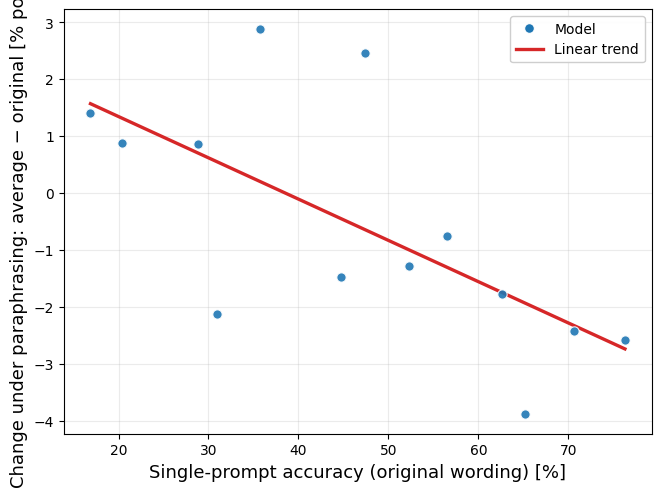

In [49]:
df["Delta_AvgMinusOrig"] = df["Average_Acc"] - df["Orig_Acc"]
_scatter_with_refs(
    df["Orig_Acc"].to_numpy(),
    df["Delta_AvgMinusOrig"].to_numpy(),
    xlabel="Single-prompt accuracy (original wording) [%]",
    ylabel="Change under paraphrasing: average − original [% points]",
    title="TruthfulQA: Paraphrasing Shift vs Original Accuracy",
    outpath="orig_vs_delta_avg_minus_orig_truthfulqa.pdf",
    add_y_eq_x=False
)


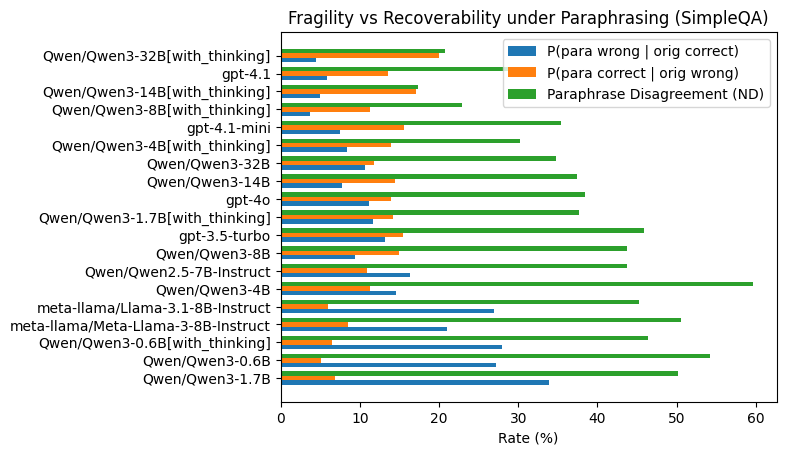

In [50]:
import numpy as np
import matplotlib.pyplot as plt

plot4 = df_flip.copy().sort_values("Orig_Acc", ascending=True)

models = plot4["model"].tolist()
y = np.arange(len(models))

fragile = plot4["A_to_notA"].values
recover = plot4["notA_to_A"].values
nd = plot4["ND"].values

plt.figure()
# Simple horizontal bar layout using offsets
h = 0.25
plt.barh(y - h, fragile, height=h, label="P(para wrong | orig correct)")
plt.barh(y,     recover, height=h, label="P(para correct | orig wrong)")
plt.barh(y + h, nd,      height=h, label="Paraphrase Disagreement (ND)")

plt.yticks(y, models)
plt.xlabel("Rate (%)")
plt.title("Fragility vs Recoverability under Paraphrasing (SimpleQA)")
plt.legend()
plt.show()
